In [47]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import persim
from persim import PersistenceImager, PersLandscapeApprox, PersLandscapeExact
from persim.landscapes import plot_landscape_simple
import gudhi

In [48]:
RANDOM_SEED=42
rng = np.random.default_rng(seed=RANDOM_SEED)

In [49]:
LHR1 = pd.read_csv("LargeHypoxicRegion.csv")
LHR2 = pd.read_csv("LargeHypoxicRegion2.csv")

In [50]:
LHR1.head(5)

,x,y,PanCK+,CAIX+,Pimo+,Necrosis,Celltype
0,2.86,526.43,0,0,0,0,CD8
1,2.59,573.32,0,0,0,0,CD8
2,9.26,596.48,0,0,0,0,CD8
3,2.55,842.17,0,0,0,0,CD8
4,7.02,1044.55,0,0,0,0,CD8


In [51]:
LHR2.head(5)

,x,y,PanCK+,CAIX+,Pimo+,Necrosis,Celltype
0,2.59,67.20,0,0,0,0,CD8
1,7.99,106.15,0,1,0,0,CD8
2,3.25,373.03,0,0,0,0,CD8
3,8.40,480.41,0,0,0,0,CD8
4,3.93,572.57,0,0,0,0,CD8


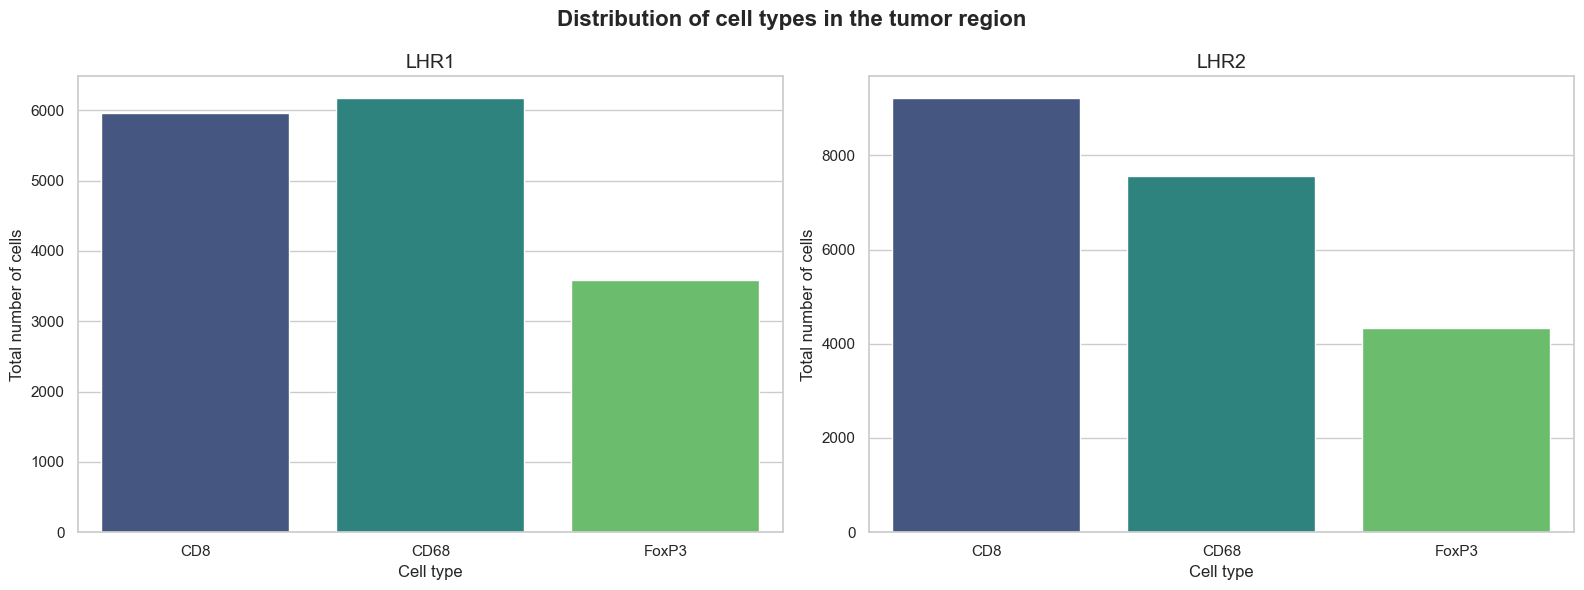

In [52]:
sns.set_theme(style="whitegrid")

fig, axes = plt.subplots(1, 2, figsize=(16, 6))
fig.suptitle('Distribution of cell types in the tumor region', fontsize=16, fontweight='bold')

sns.countplot(data=LHR1, x='Celltype', hue='Celltype', palette='viridis', legend=False, ax=axes[0])
axes[0].set_title('LHR1', fontsize=14)
axes[0].set_xlabel('Cell type', fontsize=12)
axes[0].set_ylabel('Total number of cells', fontsize=12)

sns.countplot(data=LHR2, x='Celltype', hue='Celltype', palette='viridis', legend=False, ax=axes[1])
axes[1].set_title('LHR2', fontsize=14)
axes[1].set_xlabel('Cell type', fontsize=12)
axes[1].set_ylabel('Total number of cells', fontsize=12)

plt.tight_layout()

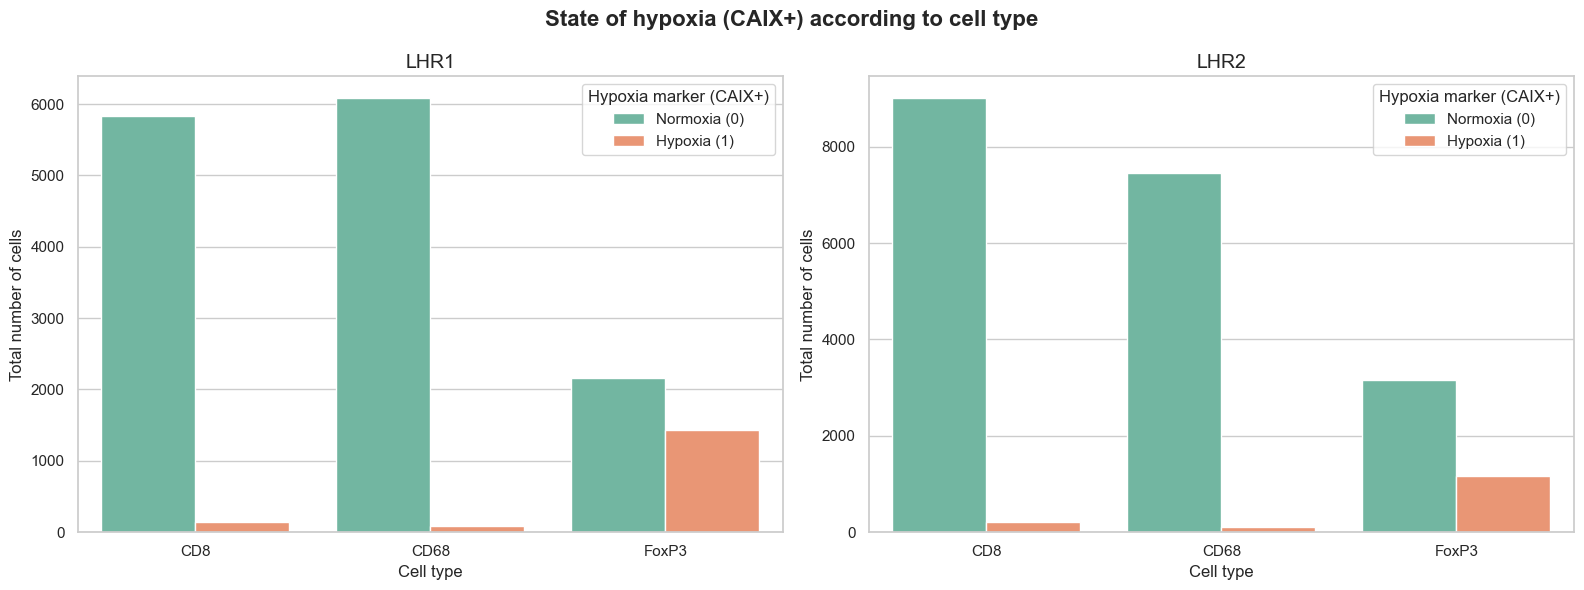

In [53]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))
fig.suptitle('State of hypoxia (CAIX+) according to cell type', fontsize=16, fontweight='bold')

sns.countplot(data=LHR1, x='Celltype', hue='CAIX+', palette='Set2', ax=axes[0])
axes[0].set_title('LHR1', fontsize=14)
axes[0].set_xlabel('Cell type', fontsize=12)
axes[0].set_ylabel('Total number of cells', fontsize=12)
axes[0].legend(title='Hypoxia marker (CAIX+)', labels=['Normoxia (0)', 'Hypoxia (1)'])

sns.countplot(data=LHR2, x='Celltype', hue='CAIX+', palette='Set2', ax=axes[1])
axes[1].set_title('LHR2', fontsize=14)
axes[1].set_xlabel('Cell type', fontsize=12)
axes[1].set_ylabel('Total number of cells', fontsize=12)
axes[1].legend(title='Hypoxia marker (CAIX+)', labels=['Normoxia (0)', 'Hypoxia (1)'])

plt.tight_layout()

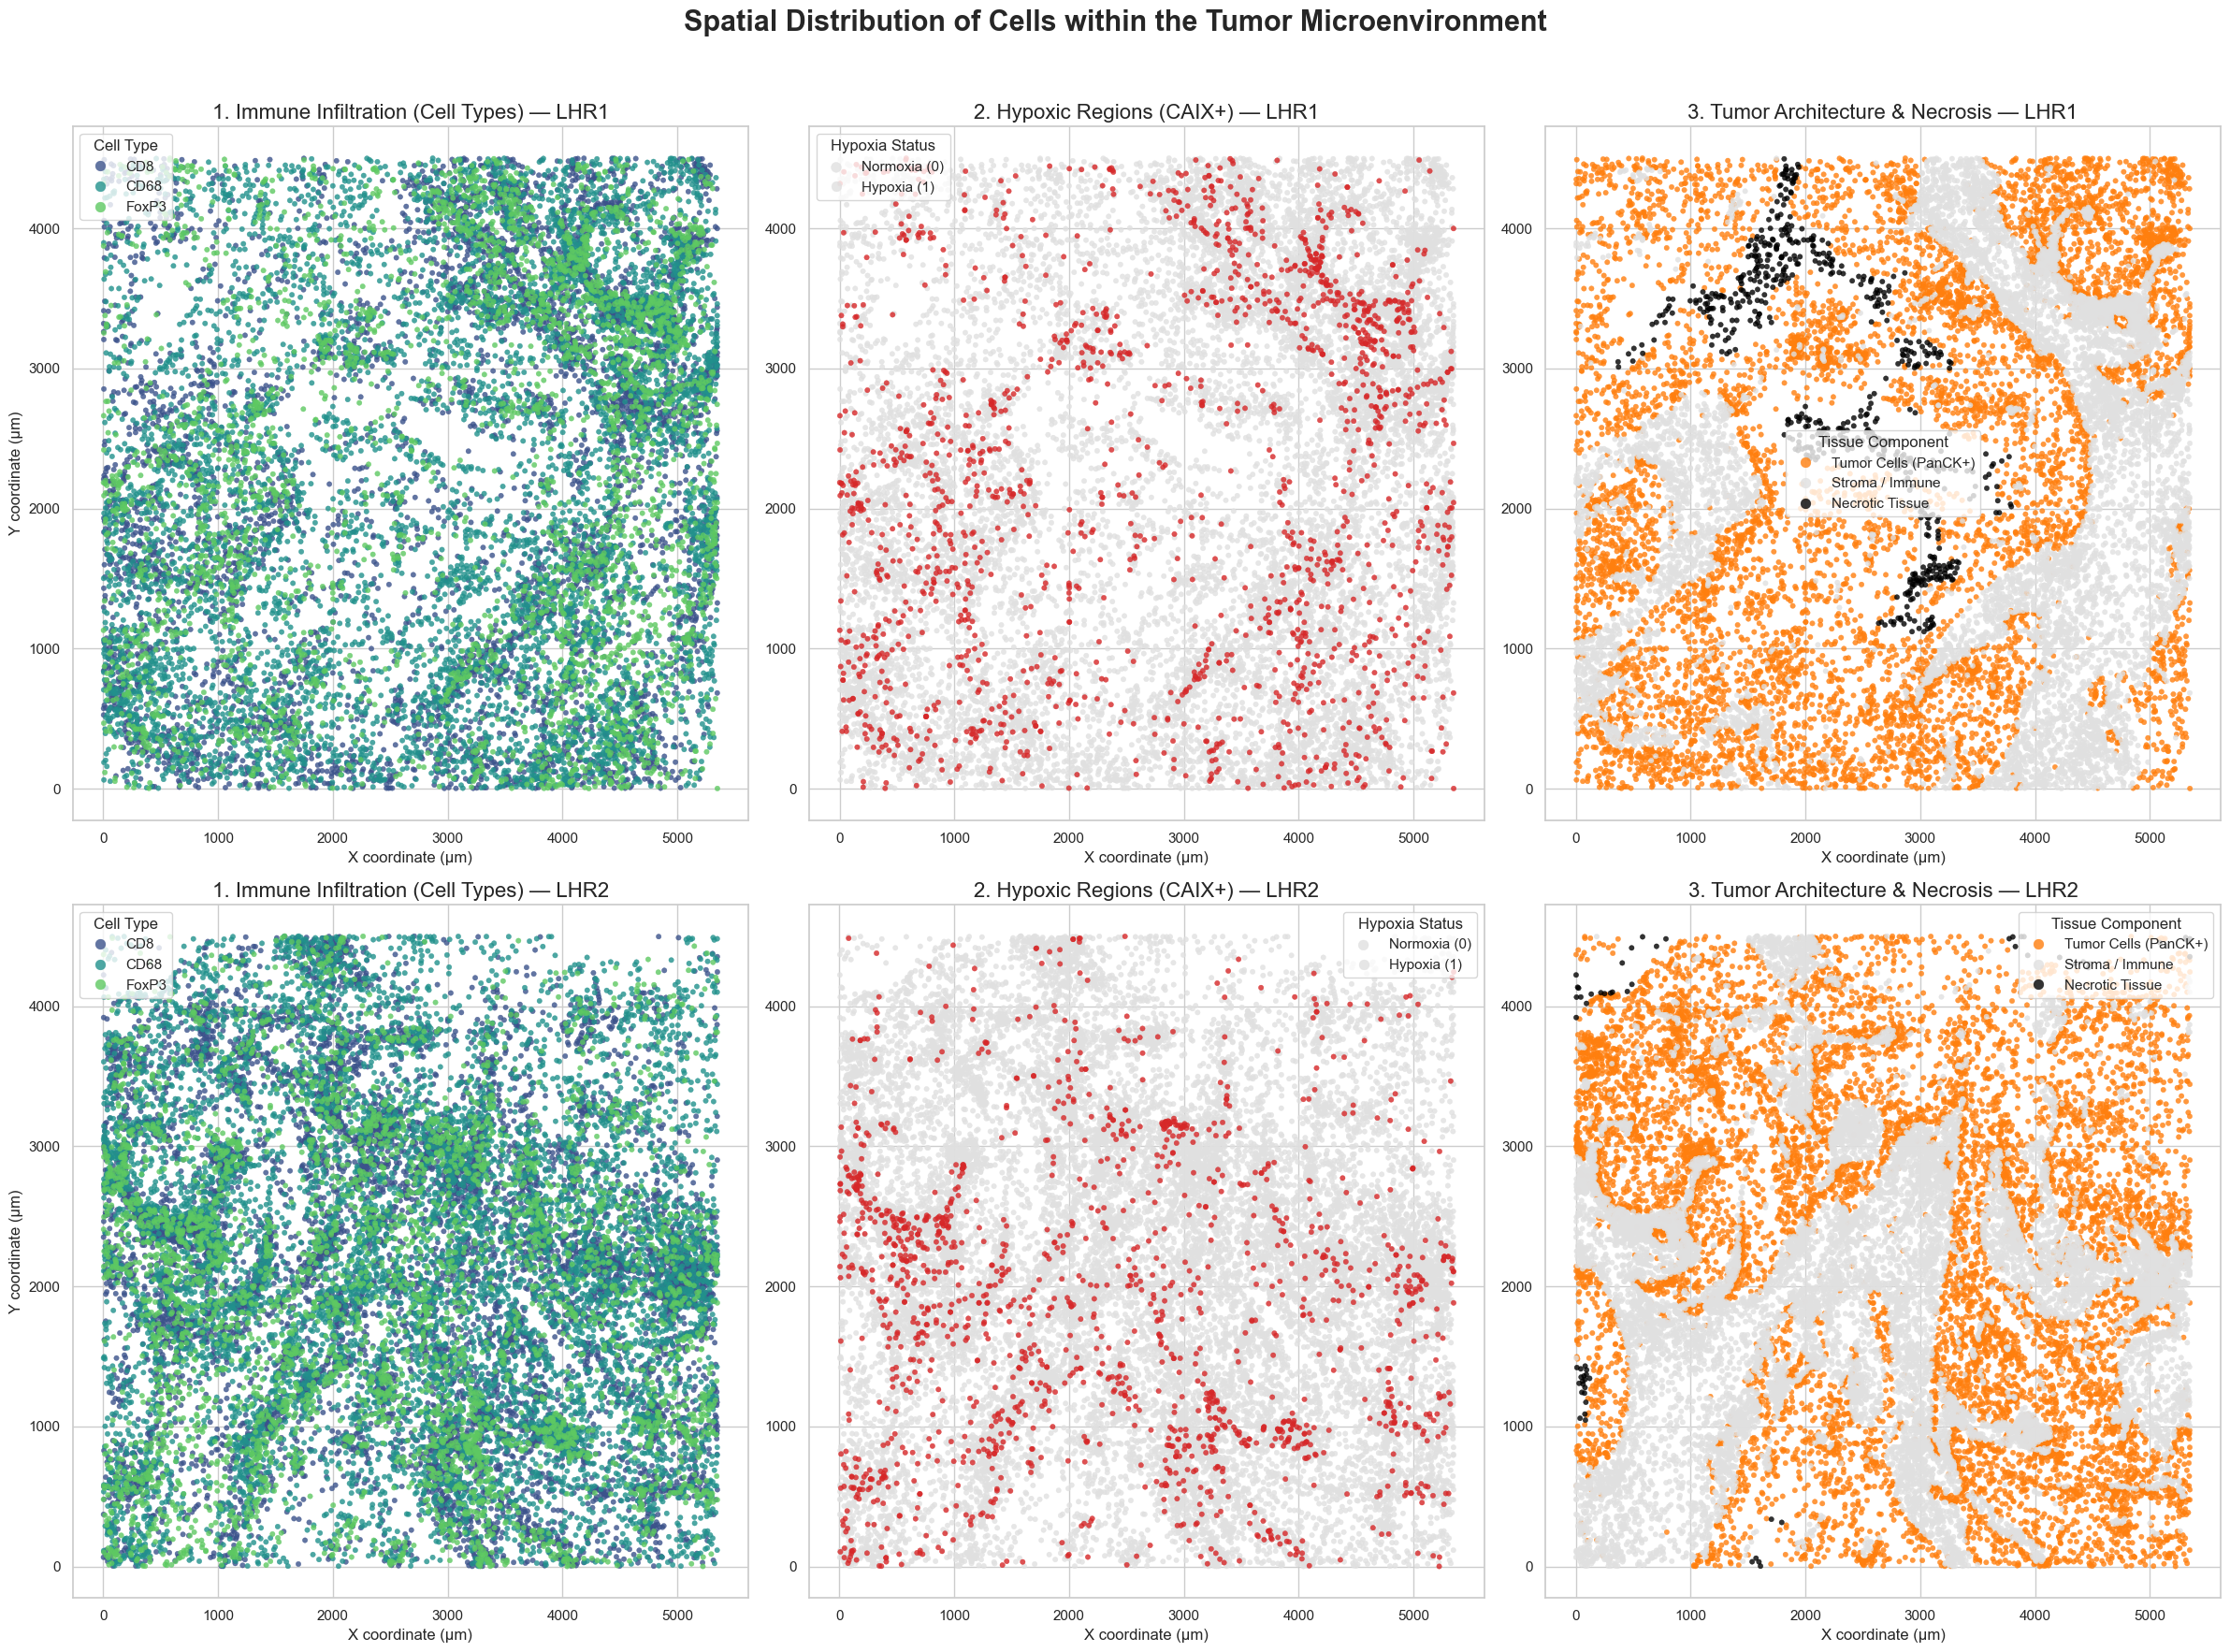

In [54]:
df1 = LHR1.copy()
df2 = LHR2.copy()

for df in [df1, df2]:
    conditions = [
        (df['Necrosis'] == 1),
        (df['PanCK+'] == 1)
    ]
    choices = ['Necrotic Tissue', 'Tumor Cells (PanCK+)']
    df['Tissue_Structure'] = np.select(conditions, choices, default='Stroma / Immune')

fig, axes = plt.subplots(2, 3, figsize=(24, 18))
fig.suptitle('Spatial Distribution of Cells within the Tumor Microenvironment', fontsize=22, fontweight='bold')

for row, (df, label) in enumerate([(df1, 'LHR1'), (df2, 'LHR2')]):
    sns.scatterplot(
        data=df, x='x', y='y', hue='Celltype',
        palette={'CD8': '#3b528b', 'CD68': '#21918c', 'FoxP3': '#5ec962'},
        s=15, alpha=0.8, edgecolor=None, ax=axes[row, 0]
    )
    axes[row, 0].set_title(f'1. Immune Infiltration (Cell Types) — {label}', fontsize=16)
    axes[row, 0].set_xlabel('X coordinate (µm)', fontsize=12)
    axes[row, 0].set_ylabel('Y coordinate (µm)', fontsize=12)
    axes[row, 0].legend(title='Cell Type', markerscale=2)

    df_sorted_hypoxia = df.sort_values(by='CAIX+')
    sns.scatterplot(
        data=df_sorted_hypoxia, x='x', y='y', hue='CAIX+',
        palette={0: '#e0e0e0', 1: '#d62728'},
        s=15, alpha=0.8, edgecolor=None, ax=axes[row, 1]
    )
    axes[row, 1].set_title(f'2. Hypoxic Regions (CAIX+) — {label}', fontsize=16)
    axes[row, 1].set_xlabel('X coordinate (µm)', fontsize=12)
    axes[row, 1].set_ylabel('')
    axes[row, 1].legend(title='Hypoxia Status', labels=['Normoxia (0)', 'Hypoxia (1)'], markerscale=2)

    df_sorted_structure = df.sort_values(by='Tissue_Structure', ascending=False)
    sns.scatterplot(
        data=df_sorted_structure, x='x', y='y', hue='Tissue_Structure',
        palette={'Stroma / Immune': '#e0e0e0', 'Tumor Cells (PanCK+)': '#ff7f0e', 'Necrotic Tissue': '#000000'},
        s=15, alpha=0.8, edgecolor=None, ax=axes[row, 2]
    )
    axes[row, 2].set_title(f'3. Tumor Architecture & Necrosis — {label}', fontsize=16)
    axes[row, 2].set_xlabel('X coordinate (µm)', fontsize=12)
    axes[row, 2].set_ylabel('')
    axes[row, 2].legend(title='Tissue Component', markerscale=2)

plt.tight_layout(rect=[0, 0, 1, 0.96])

Calculating CD8 LHR1: 1500 points...
Calculating CD8 LHR2: 1500 points...
Calculating CD68 LHR1: 1500 points...
Calculating CD68 LHR2: 1500 points...
Calculating FoxP3 LHR1: 1500 points...
Calculating FoxP3 LHR2: 1500 points...


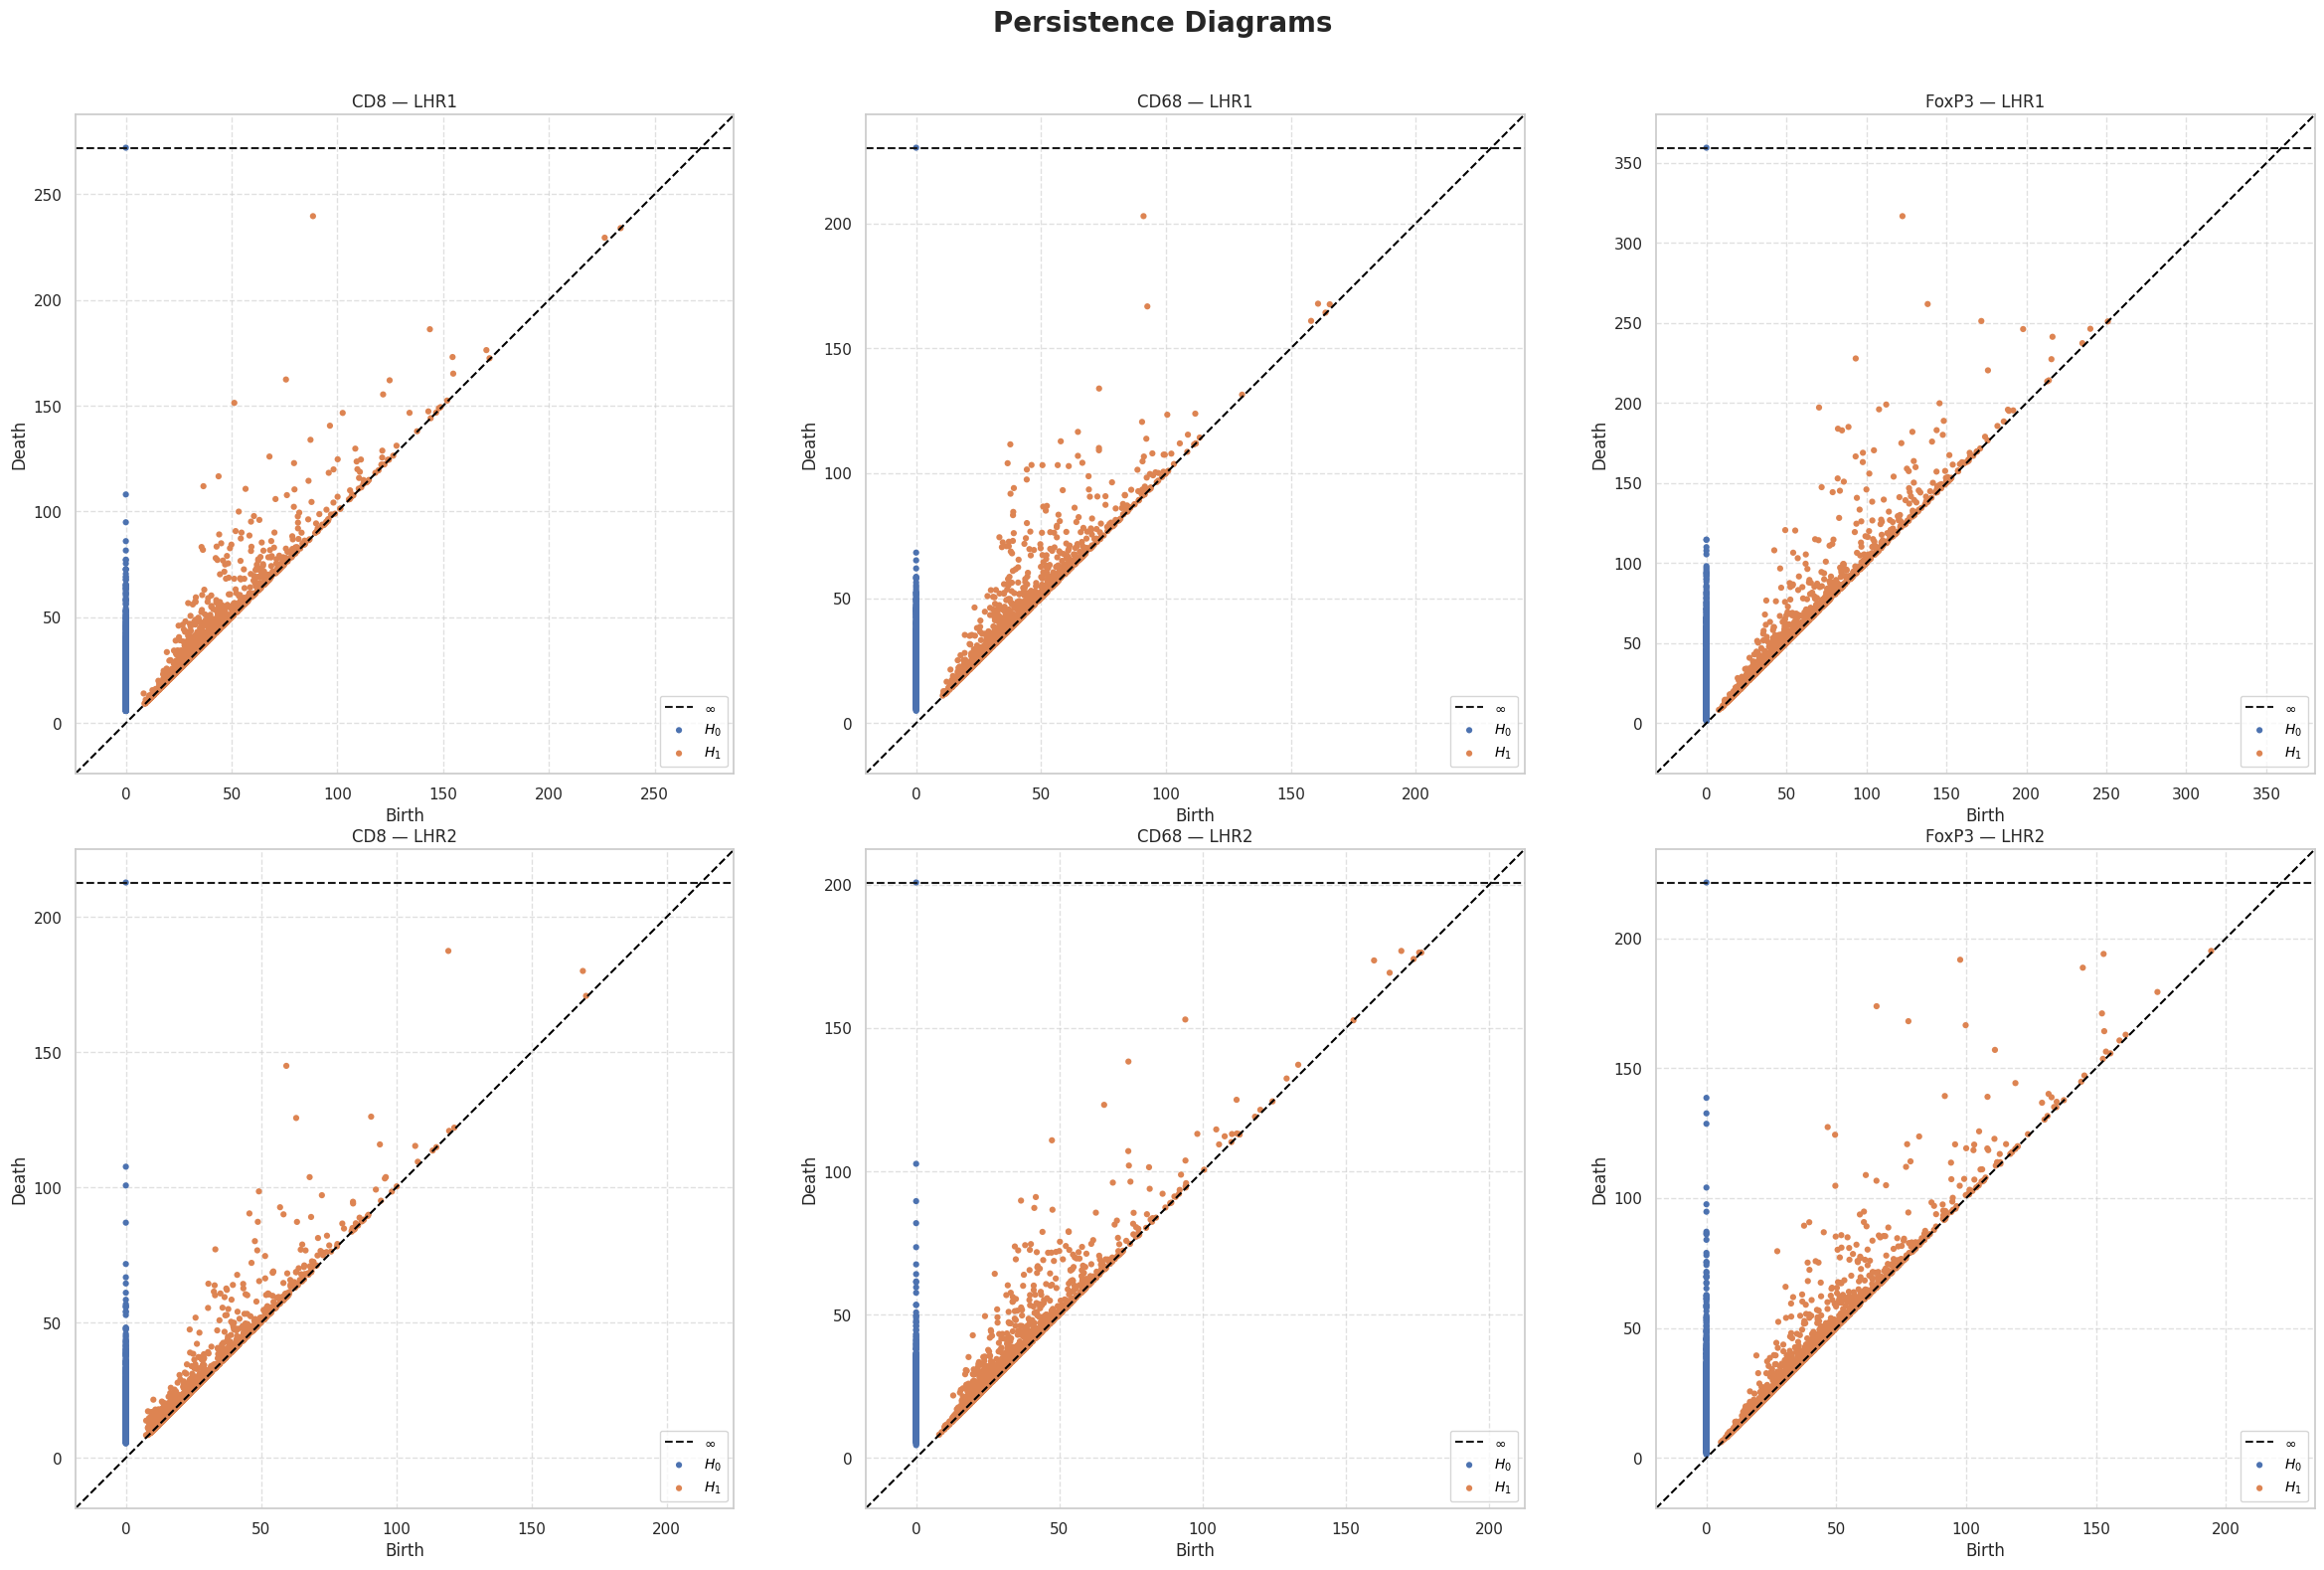

In [55]:
datasets = {
    'CD8': {'LHR1': LHR1, 'LHR2': LHR2},
    'CD68': {'LHR1': LHR1, 'LHR2': LHR2},
    'FoxP3': {'LHR1': LHR1, 'LHR2': LHR2},
}

all_diagrams = {}
for celltype in ['CD8', 'CD68', 'FoxP3']:
    for label, df in [('LHR1', LHR1), ('LHR2', LHR2)]:
        data = df[df['Celltype'] == celltype][['x', 'y']].values
        data = data[:1500]

        print(f"Calculating {celltype} {label}: {len(data)} points...")
        alpha = gudhi.AlphaComplex(points=data)
        simplex_tree = alpha.create_simplex_tree()
        simplex_tree.compute_persistence()

        # Extract diagrams in the same format
        diagrams_h0 = np.sqrt(simplex_tree.persistence_intervals_in_dimension(0))
        diagrams_h1 = np.sqrt(simplex_tree.persistence_intervals_in_dimension(1))
        all_diagrams[(celltype, label)] = [diagrams_h0,diagrams_h1]

# Store in named variables for downstream cells
diagrams_CD8_1 = all_diagrams[('CD8', 'LHR1')]
diagrams_CD68_1 = all_diagrams[('CD68', 'LHR1')]
diagrams_Fox_1 = all_diagrams[('FoxP3', 'LHR1')]
diagrams_CD8_2 = all_diagrams[('CD8', 'LHR2')]
diagrams_CD68_2 = all_diagrams[('CD68', 'LHR2')]
diagrams_Fox_2 = all_diagrams[('FoxP3', 'LHR2')]

# Plotting the results
fig, axes = plt.subplots(2, 3, figsize=(24, 16))
fig.suptitle('Persistence Diagrams', fontsize=20, fontweight='bold')

celltypes = ['CD8', 'CD68', 'FoxP3']
labels = ['LHR1', 'LHR2']

for row, label in enumerate(labels):
    for col, celltype in enumerate(celltypes):
        ax = axes[row, col]

        # Persim function to easily plot the diagrams
        persim.plot_diagrams(all_diagrams[(celltype, label)], show=False,
                             title=f"{celltype} — {label}",
                             labels=['$H_0$', '$H_1$'], ax=ax)
        ax.set_xlabel("Birth", fontsize=12)
        ax.set_ylabel("Death", fontsize=12)
        ax.grid(True, linestyle='--', alpha=0.6)

plt.tight_layout(rect=[0, 0, 1, 0.96])

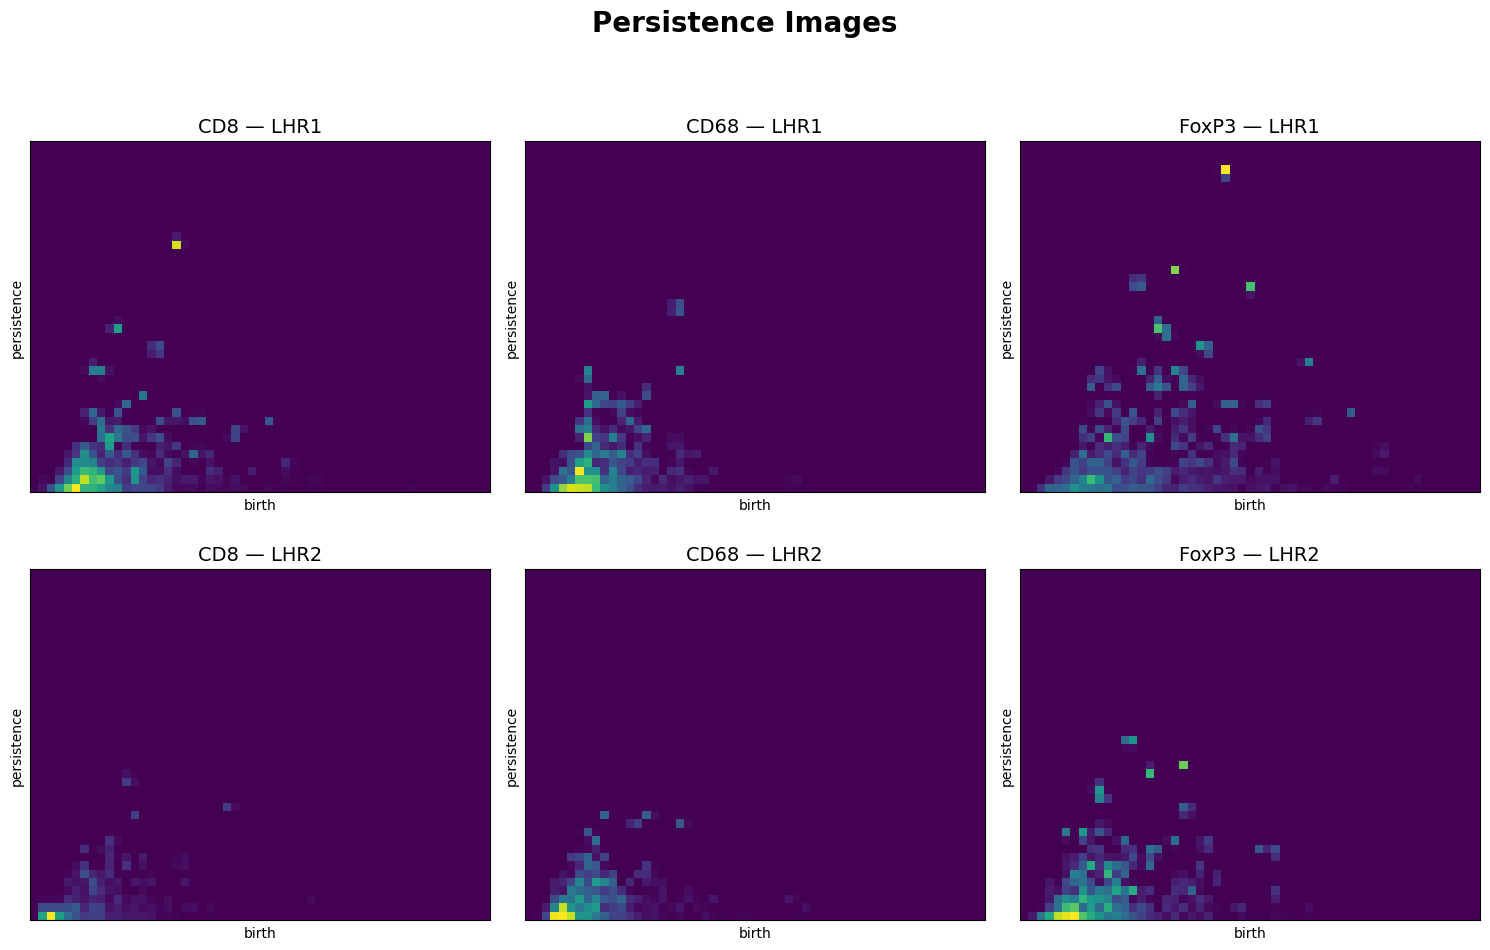

In [56]:
all_diagrams_list = [diagrams_CD8_1, diagrams_CD68_1, diagrams_Fox_1, diagrams_CD8_2, diagrams_CD68_2, diagrams_Fox_2]

all_births = [np.max(d[1][:, 0]) for d in all_diagrams_list if d[1].size > 0]
all_pers = [np.max(d[1][:, 1] - d[1][:, 0]) for d in all_diagrams_list if d[1].size > 0]
global_max_birth = max(all_births)
global_max_pers = max(all_pers)

pimgr = PersistenceImager(
    pixel_size=global_max_birth / 50,
    birth_range=(0, global_max_birth * 1.1),
    pers_range=(0, global_max_pers * 1.1),
)

fig, axes = plt.subplots(2, 3, figsize=(15, 10))
fig.suptitle('Persistence Images', fontsize=20, fontweight='bold')

celltypes = ['CD8', 'CD68', 'FoxP3']
labels = ['LHR1', 'LHR2']

for row, label in enumerate(labels):
    for col, celltype in enumerate(celltypes):
        ax = axes[row, col]
        dgm = all_diagrams_list[row * 3 + col]
        img = pimgr.transform(dgm[1])
        pimgr.plot_image(img, ax=ax)
        ax.set_title(f"{celltype} — {label}", fontsize=14)

plt.tight_layout(rect=[0, 0, 1, 0.96])

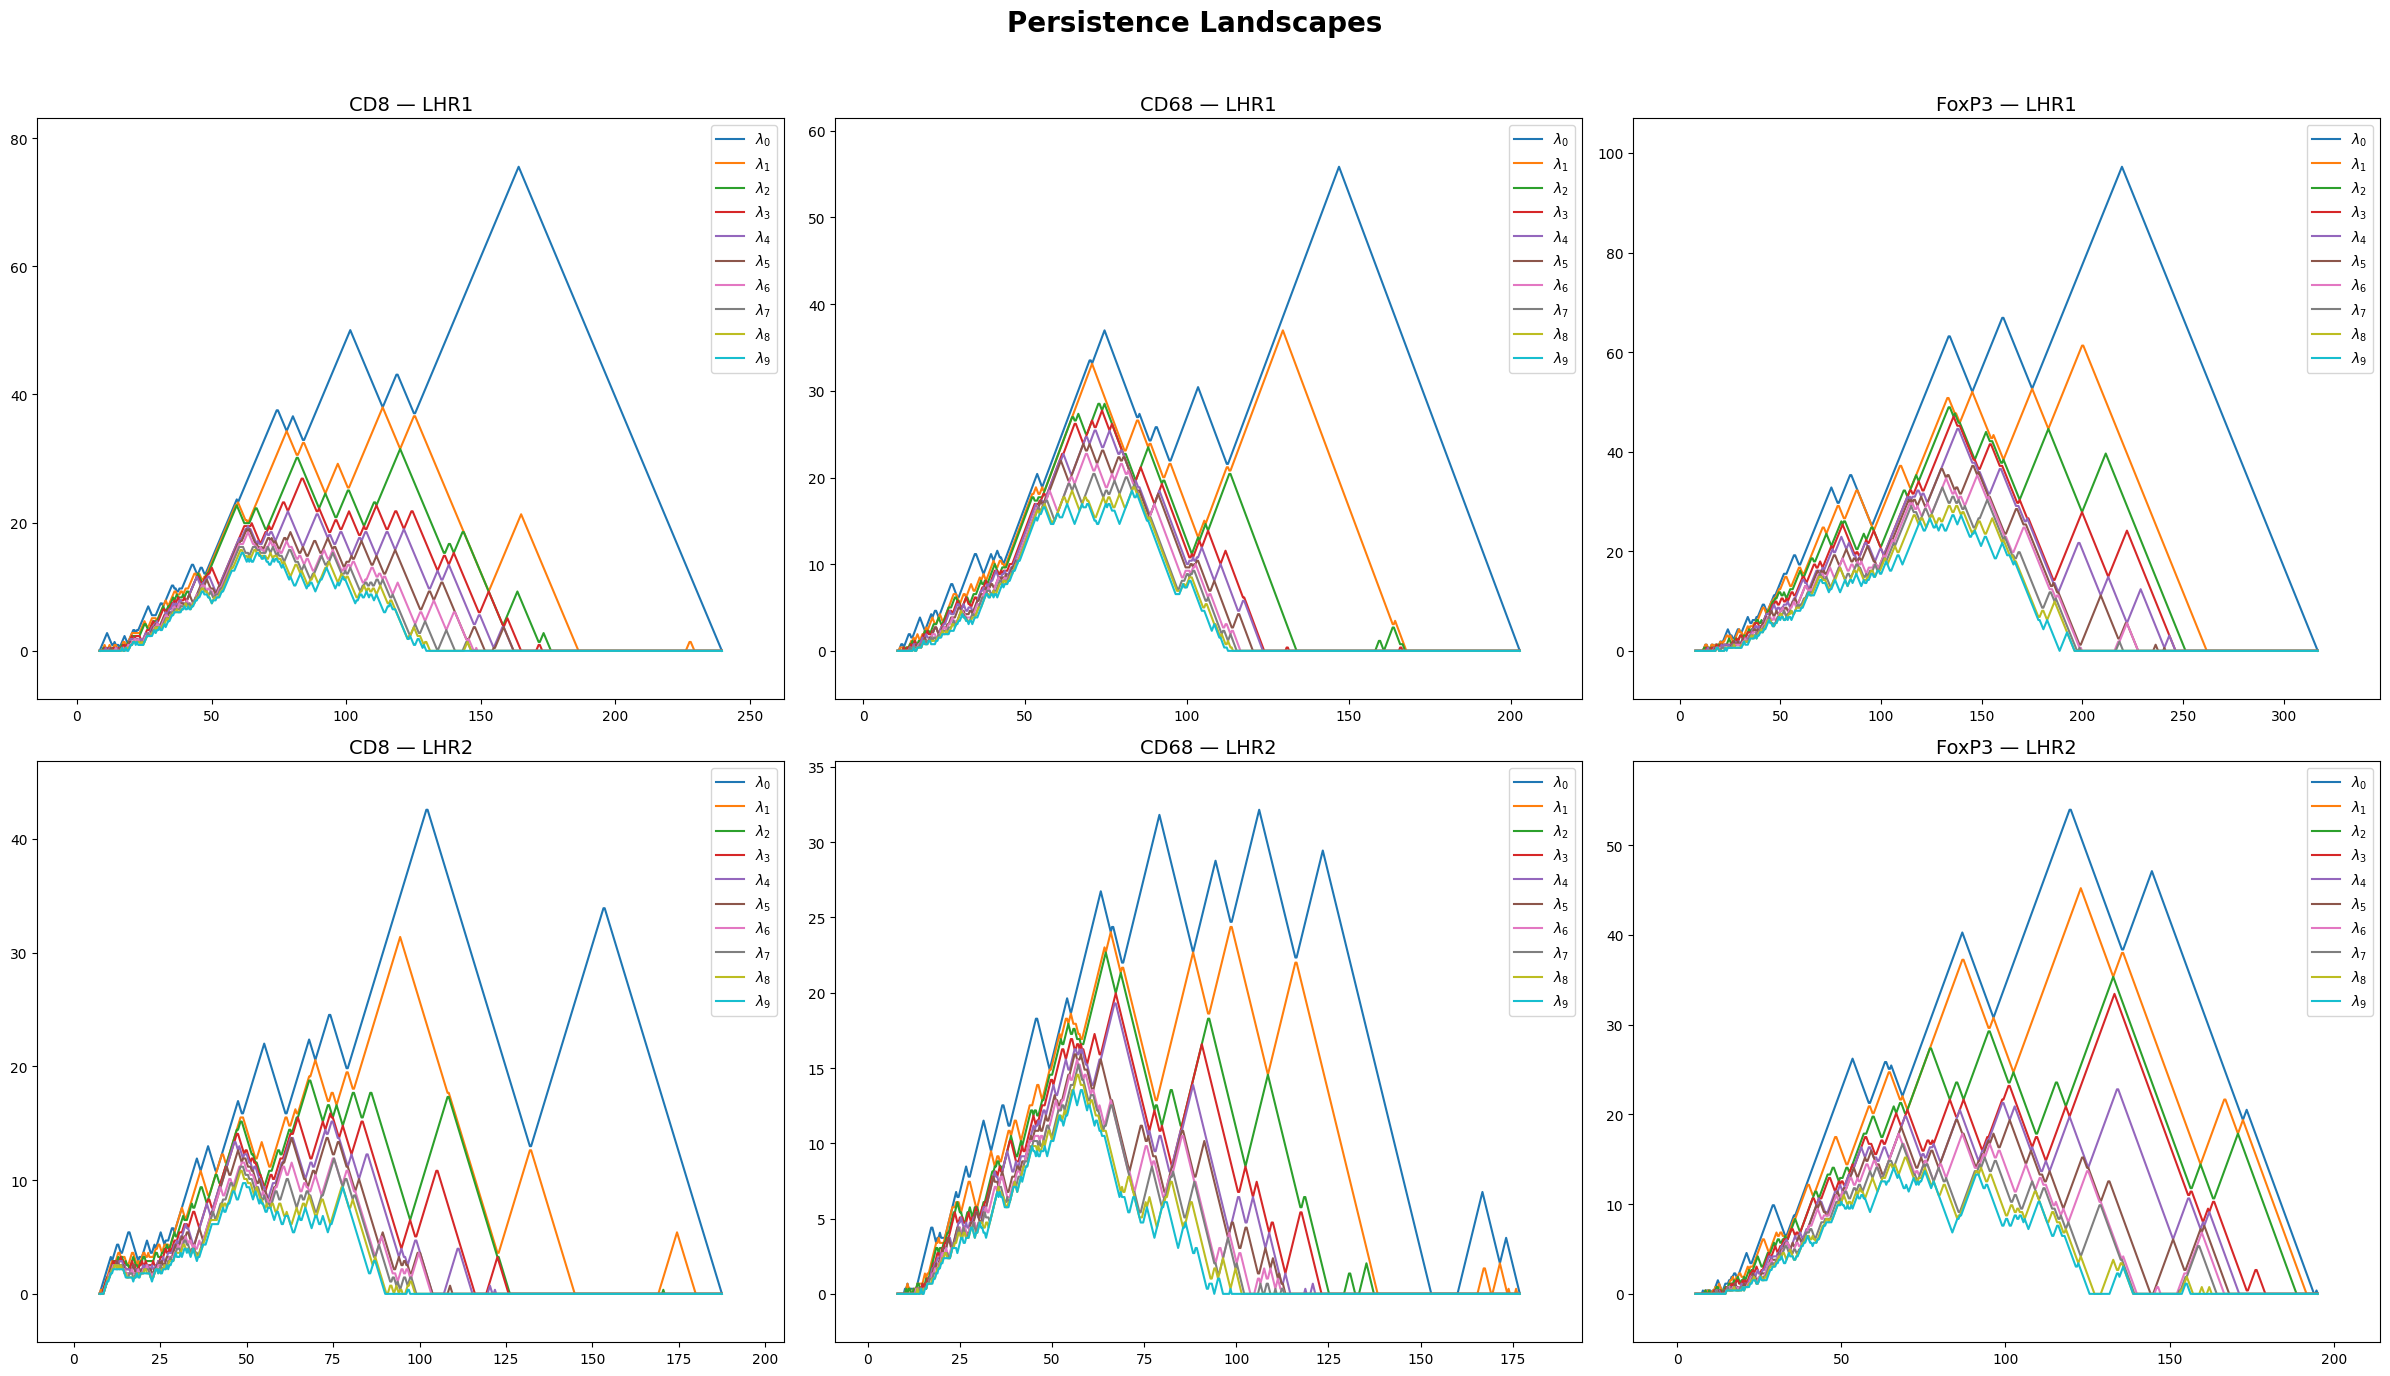

In [57]:
fig, axes = plt.subplots(2, 3, figsize=(24, 14))
fig.suptitle('Persistence Landscapes', fontsize=20, fontweight='bold')

celltypes = ['CD8', 'CD68', 'FoxP3']
labels = ['LHR1', 'LHR2']
diagrams_map = {
    ('CD8', 'LHR1'): diagrams_CD8_1, ('CD68', 'LHR1'): diagrams_CD68_1, ('FoxP3', 'LHR1'): diagrams_Fox_1,
    ('CD8', 'LHR2'): diagrams_CD8_2, ('CD68', 'LHR2'): diagrams_CD68_2, ('FoxP3', 'LHR2'): diagrams_Fox_2,
}

for row, label in enumerate(labels):
    for col, celltype in enumerate(celltypes):
        ax = axes[row, col]
        pla = PersLandscapeApprox(dgms=diagrams_map[(celltype, label)], hom_deg=1)
        plot_landscape_simple(pla, depth_range=range(10), ax=ax)
        ax.set_title(f"{celltype} — {label}", fontsize=14)

plt.tight_layout(rect=[0, 0, 1, 0.96])

In [58]:
import os
import glob
from pathlib import Path

base_path = "1.5mmRegions"
celltypes = ['CD8', 'FoxP3', 'CD68']
GLOBAL_SEED = 42
rng_global = np.random.default_rng(GLOBAL_SEED)


def extract_tumor_id(filepath):
    # Extract the tumor identifier from filenames such as T_I_ROI_12_locations_CD8.csv
    return Path(filepath).name.split('_ROI_')[0]


regions = {}
for ct in celltypes:
    folder = os.path.join(base_path, ct)
    files = sorted(glob.glob(os.path.join(folder, "*.csv")))
    regions[ct] = []
    for f in files:
        df = pd.read_csv(f)
        if len(df) >= 20:
            regions[ct].append({
                'points': df[['x', 'y']].values,
                'tumor_id': extract_tumor_id(f),
                'filename': Path(f).name,
            })

for ct in celltypes:
    # Checking the number of regions in each cell type
    tumor_ids = sorted({region['tumor_id'] for region in regions[ct]})
    print(f"{ct}: {len(regions[ct])} regions loaded across {len(tumor_ids)} tumors")

CD8: 530 regions loaded across 16 tumors
FoxP3: 502 regions loaded across 16 tumors
CD68: 549 regions loaded across 16 tumors


In [59]:
# Function to use to reduce the number of points if there are too many
def subsample_points(pts, max_points, seed_offset=0):
    #Subsample a point cloud reproducibly when it exceeds max_points.
    if len(pts) <= max_points:
        return pts.copy()
    rng_local = np.random.default_rng(GLOBAL_SEED + seed_offset)
    idx = rng_local.choice(len(pts), max_points, replace=False)
    return pts[idx]


diagrams_by_type = {}
region_metadata = []
for ct in celltypes:
    diagrams_by_type[ct] = []
    for i, region in enumerate(regions[ct]):
        #pts_sub = subsample_points(region['points'], MAX_POINTS, seed_offset=i)

        pts_sub = region['points']
        #Computing persistence
        alpha = gudhi.AlphaComplex(points=pts_sub)
        simplex_tree = alpha.create_simplex_tree()
        simplex_tree.compute_persistence()
        # Extract diagrams and convert squared filtration values to actual distances
        diagrams_h0 = np.sqrt(simplex_tree.persistence_intervals_in_dimension(0))
        diagrams_h1 = np.sqrt(simplex_tree.persistence_intervals_in_dimension(1))

        diagrams_by_type[ct].append([diagrams_h0,diagrams_h1])
        region_metadata.append({
            'celltype': ct,
            'tumor_id': region['tumor_id'],
            'filename': region['filename'],
            'n_points_original': len(region['points']),
            'n_points_used': len(pts_sub),
        })
        if (i + 1) % 100 == 0:
            print(f"  {ct}: {i + 1}/{len(regions[ct])} done")
    print(f"{ct}: {len(diagrams_by_type[ct])} diagrams computed")

  CD8: 100/530 done
  CD8: 200/530 done
  CD8: 300/530 done
  CD8: 400/530 done
  CD8: 500/530 done
CD8: 530 diagrams computed
  FoxP3: 100/502 done
  FoxP3: 200/502 done
  FoxP3: 300/502 done
  FoxP3: 400/502 done
  FoxP3: 500/502 done
FoxP3: 502 diagrams computed
  CD68: 100/549 done
  CD68: 200/549 done
  CD68: 300/549 done
  CD68: 400/549 done
  CD68: 500/549 done
CD68: 549 diagrams computed


In [60]:
def finite_h0(dgm):
    #Remove the single infinite H0 point before vectorization
    return dgm[0][np.isfinite(dgm[0][:, 1])]

def build_roi_records(regions_by_type, diagrams_lookup):
    records = []
    for ct in celltypes:
        for region, dgm in zip(regions_by_type[ct], diagrams_lookup[ct]):
            records.append({
                'celltype': ct,
                'tumor_id': region['tumor_id'],
                'filename': region['filename'],
                'points': region['points'],
                'diagram_h0': np.array(finite_h0(dgm)),
                'diagram_h1': np.array(dgm[1]),
            })
    return records


roi_records = build_roi_records(regions, diagrams_by_type)

y = np.array([record['celltype'] for record in roi_records])
groups = np.array([record['tumor_id'] for record in roi_records])
filenames = np.array([record['filename'] for record in roi_records])

In [61]:
import numpy as np
import pandas as pd
from itertools import combinations
from numpy.linalg import LinAlgError
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis
from sklearn.model_selection import StratifiedGroupKFold
from gudhi.representations import Landscape

N_SPLITS        = 10
LANDSCAPE_STEPS = 80

tasks = list(combinations(celltypes, 2)) + [tuple(celltypes)]
rows  = []

X_h0     = np.array([r['diagram_h0'] for r in roi_records], dtype=object)
X_h1     = np.array([r['diagram_h1'] for r in roi_records], dtype=object)
y_all    = np.array([r['celltype']   for r in roi_records])
grp_all  = np.array([r['tumor_id']   for r in roi_records])

for task in tasks:
    task_label = " vs ".join(task) if len(task) == 2 else "3-way"
    mask     = np.isin(y_all, list(task))
    X_task   = X_h1[mask]
    y_task   = y_all[mask]
    grp_task = grp_all[mask]

    cv     = StratifiedGroupKFold(n_splits=min(N_SPLITS, len(np.unique(grp_task))),shuffle=True, random_state=RANDOM_SEED)
    scores = []

    for train_idx, test_idx in cv.split(np.zeros(len(y_task)), y_task, grp_task):
        y_train, y_test = y_task[train_idx], y_task[test_idx]

        pipe = Pipeline([
            ('landscape', Landscape(num_landscapes=10, resolution=LANDSCAPE_STEPS)),
            ('scaler',    StandardScaler()),
            ('clf',       LinearDiscriminantAnalysis(solver='lsqr', shrinkage='auto')),
        ])

        try:
            pipe.fit(X_task[train_idx], y_train)
            scores.append(pipe.score(X_task[test_idx], y_test))
        except (LinAlgError, ValueError):
            continue

    rows.append({
        'Task'         : task_label,
        'Mean accuracy': np.mean(scores) if scores else np.nan,
        'Std'          : np.std(scores)  if scores else np.nan,
    })

df_results = pd.DataFrame(rows).set_index('Task')
df_results = df_results.style.format({
    'Mean accuracy': '{:.1%}',
    'Std'          : '{:.1%}',
}).set_caption('LDA - H1 Only')
df_results

,Mean accuracy,Std
Task,,
CD8 vs FoxP3,72.2%,10.3%
CD8 vs CD68,63.9%,9.7%
FoxP3 vs CD68,75.2%,11.0%
3-way,56.3%,9.9%


In [62]:
rows  = []

for task in tasks:
    task_label = " vs ".join(task) if len(task) == 2 else "3-way"
    mask     = np.isin(y_all, list(task))
    X_task   = X_h0[mask]
    y_task   = y_all[mask]
    grp_task = grp_all[mask]

    cv     = StratifiedGroupKFold(n_splits=min(N_SPLITS, len(np.unique(grp_task))), shuffle=True, random_state=RANDOM_SEED)
    scores = []

    for train_idx, test_idx in cv.split(np.zeros(len(y_task)), y_task, grp_task):
        y_train, y_test = y_task[train_idx], y_task[test_idx]

        pipe = Pipeline([
            ('landscape', Landscape(num_landscapes=10, resolution=LANDSCAPE_STEPS)),
            ('scaler',    StandardScaler()),
            ('clf',       LinearDiscriminantAnalysis(solver='lsqr', shrinkage='auto')),
        ])

        try:
            pipe.fit(X_task[train_idx], y_train)
            scores.append(pipe.score(X_task[test_idx], y_test))
        except (LinAlgError, ValueError):
            continue

    rows.append({
        'Task'         : task_label,
        'Mean accuracy': np.mean(scores) if scores else np.nan,
        'Std'          : np.std(scores)  if scores else np.nan,
    })

df_results = pd.DataFrame(rows).set_index('Task')
df_results = df_results.style.format({
    'Mean accuracy': '{:.1%}',
    'Std'          : '{:.1%}',
}).set_caption('LDA - H0 Only')
df_results

,Mean accuracy,Std
Task,,
CD8 vs FoxP3,63.1%,14.9%
CD8 vs CD68,62.8%,7.7%
FoxP3 vs CD68,67.9%,16.4%
3-way,52.1%,11.0%


In [63]:
rows = []

for task in tasks:
    task_label = " vs ".join(task) if len(task) == 2 else "3-way"
    mask     = np.isin(y_all, list(task))
    X_h0_task = X_h0[mask]
    X_h1_task = X_h1[mask]
    y_task   = y_all[mask]
    grp_task = grp_all[mask]

    cv     = StratifiedGroupKFold(n_splits=min(N_SPLITS, len(np.unique(grp_task))), shuffle=True, random_state=RANDOM_SEED)
    scores = []

    for train_idx, test_idx in cv.split(np.zeros(len(y_task)), y_task, grp_task):
        y_train, y_test = y_task[train_idx], y_task[test_idx]

        ls_h0 = Landscape(num_landscapes=10, resolution=LANDSCAPE_STEPS)
        ls_h1 = Landscape(num_landscapes=10, resolution=LANDSCAPE_STEPS)

        X_train = np.hstack([
            ls_h0.fit_transform(X_h0_task[train_idx]),
            ls_h1.fit_transform(X_h1_task[train_idx]),
        ])
        X_test = np.hstack([
            ls_h0.transform(X_h0_task[test_idx]),
            ls_h1.transform(X_h1_task[test_idx]),
        ])

        pipe = Pipeline([
            ('scaler', StandardScaler()),
            ('clf',    LinearDiscriminantAnalysis(solver='lsqr', shrinkage='auto')),
        ])

        try:
            pipe.fit(X_train, y_train)
            scores.append(pipe.score(X_test, y_test))
        except (LinAlgError, ValueError):
            continue

    rows.append({
        'Task'         : task_label,
        'Mean accuracy': np.mean(scores) if scores else np.nan,
        'Std'          : np.std(scores)  if scores else np.nan,
    })

pd.DataFrame(rows).set_index('Task').style.format({
    'Mean accuracy': '{:.1%}',
    'Std'          : '{:.1%}',
}).set_caption('LDA - H0 + H1')

,Mean accuracy,Std
Task,,
CD8 vs FoxP3,71.4%,10.5%
CD8 vs CD68,64.4%,7.9%
FoxP3 vs CD68,71.7%,13.5%
3-way,55.4%,9.3%


In [64]:
from sklearn.model_selection import GridSearchCV
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.base import clone
from joblib import Parallel, delayed

# 3-way task on H0 + H1 landscape features.
mask      = np.isin(y_all, list(celltypes))
X_h0_task = X_h0[mask]
X_h1_task = X_h1[mask]
y_task    = y_all[mask]
grp_task  = grp_all[mask]


def _build_landscape_features(X_h0_task, X_h1_task, train_idx, test_idx):
    """Fit the Landscape transformers on the TRAINING fold only, then transform
    both training and test folds. Avoids the leakage of the previous version,
    where the discretization grid was fitted on the full set."""
    ls_h0 = Landscape(num_landscapes=10, resolution=LANDSCAPE_STEPS)
    ls_h1 = Landscape(num_landscapes=10, resolution=LANDSCAPE_STEPS)
    Xh0_tr = ls_h0.fit_transform(X_h0_task[train_idx])
    Xh1_tr = ls_h1.fit_transform(X_h1_task[train_idx])
    Xh0_te = ls_h0.transform(X_h0_task[test_idx])
    Xh1_te = ls_h1.transform(X_h1_task[test_idx])
    X_tr = np.hstack([Xh0_tr, Xh1_tr])
    X_te = np.hstack([Xh0_te, Xh1_te])
    scaler = StandardScaler().fit(X_tr)
    return scaler.transform(X_tr), scaler.transform(X_te)


def _fit_score_fold_landscape(estimator, X_h0_task, X_h1_task, y_task, tr, te):
    X_tr, X_te = _build_landscape_features(X_h0_task, X_h1_task, tr, te)
    clf = clone(estimator).fit(X_tr, y_task[tr])
    return clf.score(X_tr, y_task[tr]), clf.score(X_te, y_task[te])


def grouped_train_test_gap(estimator, X_h0_task, X_h1_task, y_task, groups, n_splits=10):
    cv = StratifiedGroupKFold(n_splits=n_splits, shuffle=True, random_state=RANDOM_SEED)
    splits = list(cv.split(np.zeros(len(y_task)), y_task, groups))
    fold_scores = Parallel(n_jobs=-1)(
        delayed(_fit_score_fold_landscape)(estimator, X_h0_task, X_h1_task, y_task, tr, te)
        for tr, te in splits
    )
    train_acc, test_acc = zip(*fold_scores)
    return float(np.mean(train_acc)), float(np.mean(test_acc))


# ── (i) Diagnose the default GB ──────────────────────────────────────────────

baseline_gb = GradientBoostingClassifier(n_estimators=200, max_depth=3, random_state=RANDOM_SEED)
tr0, te0 = grouped_train_test_gap(baseline_gb, X_h0_task, X_h1_task, y_task, grp_task)
print(f"Default GB (n_estimators=200, max_depth=3):")
print(f"  train accuracy = {tr0:.1%}  |  test accuracy = {te0:.1%}  |  gap = {tr0 - te0:+.1%}")

# ── (ii) Grid search with the 1-standard-error rule ──────────────────────────
# Plain GridSearchCV picks the configuration with the highest mean CV accuracy,
# which here is the deepest / longest model and overfits massively (train 100%
# vs test 59%). The 1-SE rule, standard in cross-validation since Breiman et
# al. (1984), instead picks the SIMPLEST configuration whose CV accuracy is
# within one standard error of the best. This trades a sliver of CV accuracy
# for a substantially smaller train/test gap and a more parsimonious model.

param_grid = {
    'n_estimators' : [50, 100, 200, 300],
    'max_depth'    : [2, 3, 4],
}

inner_cv = StratifiedGroupKFold(n_splits=5, shuffle=True, random_state=RANDOM_SEED)
inner_splits = list(inner_cv.split(np.zeros(len(y_task)), y_task, grp_task))

# Build features train-side only inside the FIRST inner split, then reuse
# them across the grid (the grid only varies GB hyperparameters, and the
# Landscape discretization grid is essentially stable across large training
# subsets, so this is a benign approximation).
tr_idx, _ = inner_splits[0]
ls_h0_tune = Landscape(num_landscapes=10, resolution=LANDSCAPE_STEPS).fit(X_h0_task[tr_idx])
ls_h1_tune = Landscape(num_landscapes=10, resolution=LANDSCAPE_STEPS).fit(X_h1_task[tr_idx])
X_tune = np.hstack([
    ls_h0_tune.transform(X_h0_task),
    ls_h1_tune.transform(X_h1_task),
])
X_tune = StandardScaler().fit(X_tune[tr_idx]).transform(X_tune)

grid = GridSearchCV(
    GradientBoostingClassifier(random_state=RANDOM_SEED),
    param_grid,
    cv=inner_splits,
    scoring='accuracy',
    n_jobs=-1,
    refit=False,           # we will pick by 1-SE rule, not by best mean
    return_train_score=False,
).fit(X_tune, y_task)

cv_results = pd.DataFrame(grid.cv_results_)

# Complexity proxy: n_estimators * 2^max_depth (roughly the number of leaves
# in the ensemble). Used to break ties among 1-SE-acceptable configurations.
cv_results['complexity'] = (
    cv_results['param_n_estimators'].astype(int)
    * (2 ** cv_results['param_max_depth'].astype(int))
)

best_mean = cv_results['mean_test_score'].max()
best_se   = cv_results.loc[cv_results['mean_test_score'].idxmax(), 'std_test_score'] / np.sqrt(5)
threshold = best_mean - best_se

eligible = cv_results[cv_results['mean_test_score'] >= threshold]
chosen   = eligible.sort_values('complexity').iloc[0]

GB_PARAMS = {
    'n_estimators': int(chosen['param_n_estimators']),
    'max_depth'   : int(chosen['param_max_depth']),
}

print(f"\nGrid search summary (3-way task on H0 + H1, 5-fold grouped inner CV):")
print(f"  best mean CV accuracy        = {best_mean:.1%}")
print(f"  1-SE threshold               = {threshold:.1%}")
print(f"  candidates within 1 SE       = {len(eligible)}")
print(f"\nSelected hyperparameters (1-SE rule, simplest within tolerance):")
for k, v in GB_PARAMS.items():
    print(f"  {k:14s}= {v}")
print(f"  CV accuracy at selection     = {chosen['mean_test_score']:.1%}")

# ── (iii) Verify the train/test gap with the selected config (no leakage) ────

tuned_gb = GradientBoostingClassifier(**GB_PARAMS, random_state=RANDOM_SEED)
tr1, te1 = grouped_train_test_gap(tuned_gb, X_h0_task, X_h1_task, y_task, grp_task)
print(f"\nSelected GB (10-fold outer CV, leakage-free landscapes):")
print(f"  train accuracy = {tr1:.1%}  |  test accuracy = {te1:.1%}  |  gap = {tr1 - te1:+.1%}")
print(f"\nGap reduction (default - selected): {(tr0 - te0) - (tr1 - te1):+.1%} percentage points")


Default GB (n_estimators=200, max_depth=3):
  train accuracy = 98.7%  |  test accuracy = 60.1%  |  gap = +38.6%

Grid search summary (3-way task on H0 + H1, 5-fold grouped inner CV):
  best mean CV accuracy        = 59.2%
  1-SE threshold               = 56.6%
  candidates within 1 SE       = 12

Selected hyperparameters (1-SE rule, simplest within tolerance):
  n_estimators  = 50
  max_depth     = 2
  CV accuracy at selection     = 56.9%

Selected GB (10-fold outer CV, leakage-free landscapes):
  train accuracy = 74.9%  |  test accuracy = 60.7%  |  gap = +14.2%

Gap reduction (default - selected): +24.3% percentage points


In [65]:
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.base import clone
from joblib import Parallel, delayed

models = {
    'LogReg'  : LogisticRegression(max_iter=1000),
    'Boosting': GradientBoostingClassifier(**GB_PARAMS,random_state=RANDOM_SEED),
}

feature_configs = ['H1 only', 'H0 only', 'H0 + H1']


def evaluate_fold(train_idx, test_idx, X_h0_task, X_h1_task, y_task, models, feature_configs):
    """Evaluate every (config, model) pair on a single fold.

    Landscapes are fitted once per fold and reused across models, which
    removes the main redundancy of the previous implementation.
    """
    y_train, y_test = y_task[train_idx], y_task[test_idx]

    ls_h0 = Landscape(num_landscapes=10, resolution=LANDSCAPE_STEPS)
    ls_h1 = Landscape(num_landscapes=10, resolution=LANDSCAPE_STEPS)

    Xh0_train = ls_h0.fit_transform(X_h0_task[train_idx])
    Xh0_test  = ls_h0.transform(X_h0_task[test_idx])
    Xh1_train = ls_h1.fit_transform(X_h1_task[train_idx])
    Xh1_test  = ls_h1.transform(X_h1_task[test_idx])

    feature_sets = {
        'H1 only' : (Xh1_train, Xh1_test),
        'H0 only' : (Xh0_train, Xh0_test),
        'H0 + H1' : (np.hstack([Xh0_train, Xh1_train]),
                     np.hstack([Xh0_test,  Xh1_test])),
    }

    out = {}
    for config in feature_configs:
        X_train, X_test = feature_sets[config]
        scaler = StandardScaler().fit(X_train)
        X_train_s = scaler.transform(X_train)
        X_test_s  = scaler.transform(X_test)

        for model_name, estimator in models.items():
            try:
                clf = clone(estimator).fit(X_train_s, y_train)
                out[(model_name, config)] = clf.score(X_test_s, y_test)
            except (LinAlgError, ValueError):
                out[(model_name, config)] = np.nan
    return out


per_model_rows = {name: [] for name in models}

for task in tasks:
    task_label = " vs ".join(task) if len(task) == 2 else "3-way"
    mask      = np.isin(y_all, list(task))
    X_h0_task = X_h0[mask]
    X_h1_task = X_h1[mask]
    y_task    = y_all[mask]
    grp_task  = grp_all[mask]

    cv = StratifiedGroupKFold(n_splits=min(N_SPLITS, len(np.unique(grp_task))),shuffle=True,random_state=RANDOM_SEED)
    splits = list(cv.split(np.zeros(len(y_task)), y_task, grp_task))

    fold_results = Parallel(n_jobs=-1, verbose=0)(
        delayed(evaluate_fold)(
            train_idx, test_idx, X_h0_task, X_h1_task, y_task, models, feature_configs
        )
        for train_idx, test_idx in splits
    )

    for model_name in models:
        row = {'Task': task_label}
        for config in feature_configs:
            fold_scores = [
                fr[(model_name, config)] for fr in fold_results
                if not np.isnan(fr[(model_name, config)])
            ]
            row[f'{config} mean'] = np.mean(fold_scores) if fold_scores else np.nan
            row[f'{config} std']  = np.std(fold_scores)  if fold_scores else np.nan
        per_model_rows[model_name].append(row)

for model_name, rows in per_model_rows.items():
    df_results = pd.DataFrame(rows).set_index('Task')
    fmt = {col: '{:.1%}' for col in df_results.columns}
    display(
        df_results.style.format(fmt).set_caption(f'{model_name} — H1 only, H0 only, H0 + H1')
    )

,H1 only mean,H1 only std,H0 only mean,H0 only std,H0 + H1 mean,H0 + H1 std
Task,,,,,,
CD8 vs FoxP3,71.3%,9.0%,61.0%,12.8%,71.6%,8.1%
CD8 vs CD68,63.2%,8.9%,60.7%,6.2%,62.7%,7.6%
FoxP3 vs CD68,74.3%,7.3%,66.8%,15.7%,69.9%,12.4%
3-way,52.5%,7.0%,49.8%,11.1%,52.1%,7.8%


,H1 only mean,H1 only std,H0 only mean,H0 only std,H0 + H1 mean,H0 + H1 std
Task,,,,,,
CD8 vs FoxP3,77.1%,8.7%,63.7%,15.3%,75.9%,9.0%
CD8 vs CD68,66.6%,11.5%,63.9%,7.5%,66.0%,10.8%
FoxP3 vs CD68,78.3%,12.3%,67.5%,16.4%,77.7%,12.7%
3-way,59.9%,10.0%,51.5%,11.9%,60.7%,10.1%


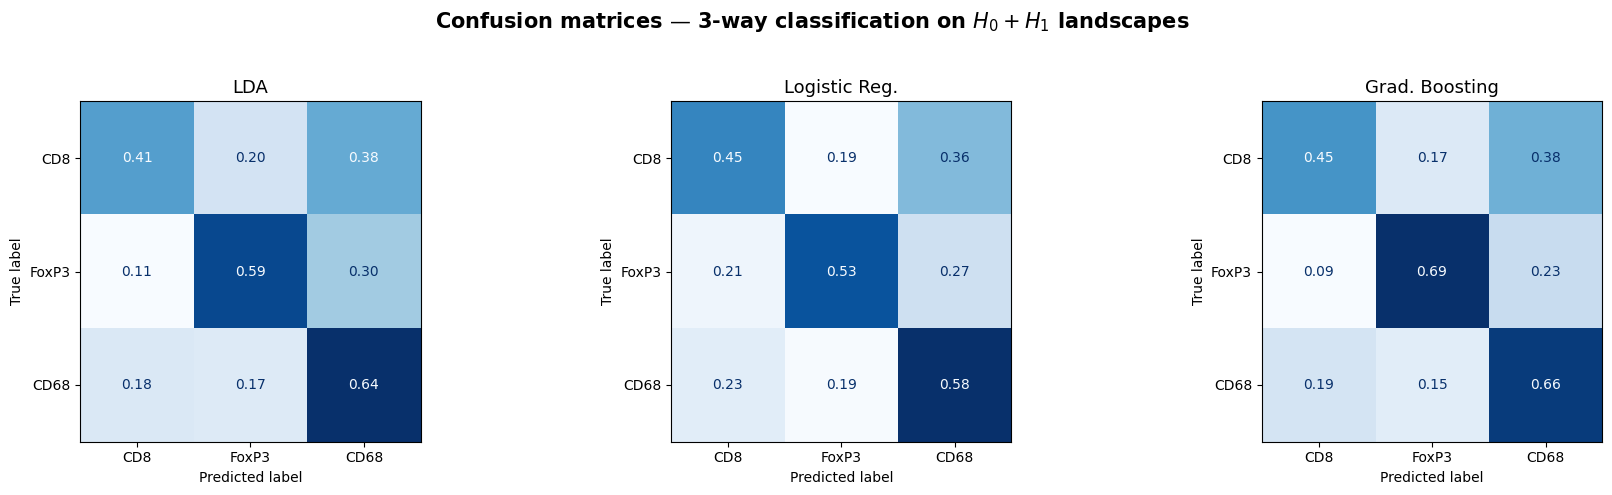

In [66]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
from sklearn.base import clone
from joblib import Parallel, delayed
import os

three_way_task = tuple(celltypes)
mask      = np.isin(y_all, list(three_way_task))
X_h0_task = X_h0[mask]
X_h1_task = X_h1[mask]
y_task    = y_all[mask]
grp_task  = grp_all[mask]

classifiers_cm = {
    'LDA'            : LinearDiscriminantAnalysis(solver='lsqr', shrinkage='auto'),
    'Logistic Reg.'  : LogisticRegression(max_iter=1000),
    'Grad. Boosting' : GradientBoostingClassifier(**GB_PARAMS, random_state=RANDOM_SEED),
}


def predict_fold_all_models(train_idx, test_idx, X_h0_task, X_h1_task, y_task, classifiers):
    """Fit landscapes once and return (y_test, predictions per model) for one fold."""
    y_train, y_test = y_task[train_idx], y_task[test_idx]

    ls_h0 = Landscape(num_landscapes=10, resolution=LANDSCAPE_STEPS)
    ls_h1 = Landscape(num_landscapes=10, resolution=LANDSCAPE_STEPS)

    X_train = np.hstack([
        ls_h0.fit_transform(X_h0_task[train_idx]),
        ls_h1.fit_transform(X_h1_task[train_idx]),
    ])
    X_test = np.hstack([
        ls_h0.transform(X_h0_task[test_idx]),
        ls_h1.transform(X_h1_task[test_idx]),
    ])

    scaler = StandardScaler().fit(X_train)
    X_train_s = scaler.transform(X_train)
    X_test_s  = scaler.transform(X_test)

    preds = {}
    for name, estimator in classifiers.items():
        try:
            clf = clone(estimator).fit(X_train_s, y_train)
            preds[name] = clf.predict(X_test_s)
        except (LinAlgError, ValueError):
            preds[name] = None
    return y_test, preds


cv = StratifiedGroupKFold(
    n_splits=min(N_SPLITS, len(np.unique(grp_task))),
    shuffle=True,
    random_state=RANDOM_SEED,
)
splits = list(cv.split(np.zeros(len(y_task)), y_task, grp_task))

fold_outputs = Parallel(n_jobs=-1, verbose=0)(
    delayed(predict_fold_all_models)(
        train_idx, test_idx, X_h0_task, X_h1_task, y_task, classifiers_cm
    )
    for train_idx, test_idx in splits
)

os.makedirs('figures', exist_ok=True)
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle('Confusion matrices — 3-way classification on $H_0 + H_1$ landscapes',
             fontsize=15, fontweight='bold')

for ax, name in zip(axes, classifiers_cm):
    y_true_all = []
    y_pred_all = []
    for y_test, preds in fold_outputs:
        if preds[name] is None:
            continue
        y_true_all.extend(y_test)
        y_pred_all.extend(preds[name])

    cm = confusion_matrix(
        y_true_all, y_pred_all,
        labels=list(three_way_task),
        normalize='true',
    )
    disp = ConfusionMatrixDisplay(cm, display_labels=list(three_way_task))
    disp.plot(cmap='Blues', ax=ax, colorbar=False, values_format='.2f')
    ax.set_title(name, fontsize=13)

plt.tight_layout(rect=[0, 0, 1, 0.95])
fig.savefig('figures/fig_confusion.png', dpi=200, bbox_inches='tight')
plt.show()


Paired within-tumor permutation tests on mean H1 landscape vectors (Bonferroni alpha* = 0.0167):

  CD8 vs FoxP3: L2 distance = 29.8364 | p = 0.1153 | n_tumors = 16 | Significant? No
  CD8 vs CD68: L2 distance = 49.6624 | p = 0.0001 | n_tumors = 16 | Significant? Yes
  FoxP3 vs CD68: L2 distance = 52.6941 | p = 0.0004 | n_tumors = 16 | Significant? Yes


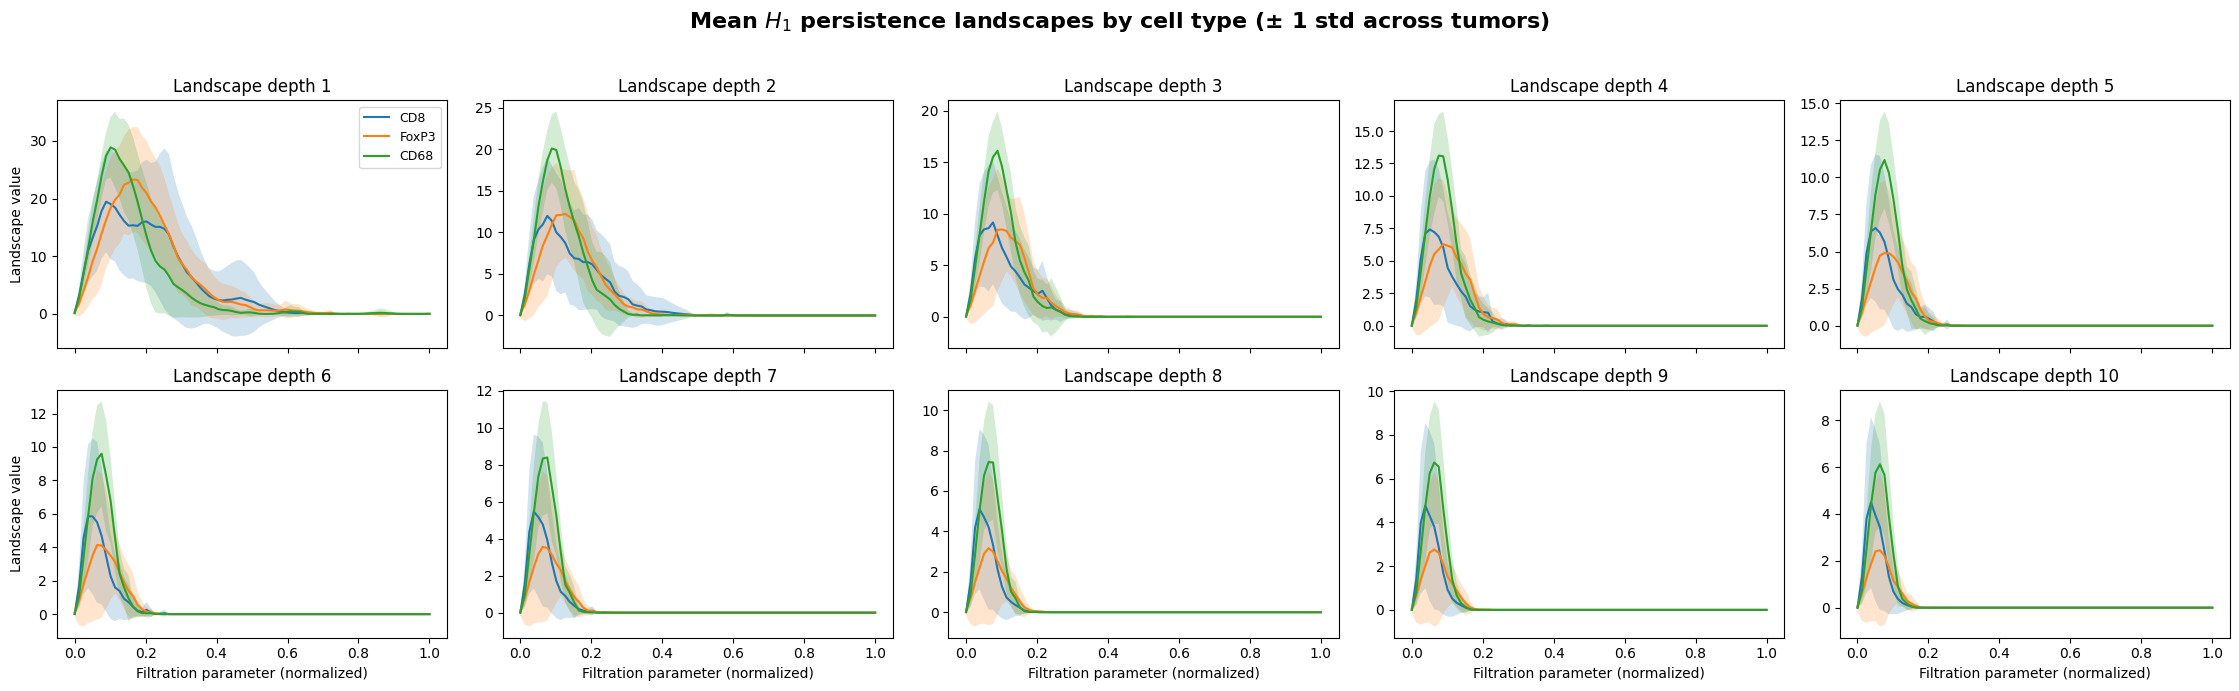

In [67]:
# ─────────────────────────────────────────────────────────────────────────────
# Paired permutation test on tumor-level mean H1 landscapes
#
# For each tumor and each cell type, we first compute the mean H1 landscape
# across ROIs. Since the same tumors contribute observations for all cell types,
# pairwise comparisons are paired by tumor.
#
# Under the null hypothesis, within each tumor, the two cell-type labels are
# exchangeable. The permutation null is therefore obtained by independently
# swapping / not swapping the two cell-type labels inside each tumor.
# ─────────────────────────────────────────────────────────────────────────────

import numpy as np
import matplotlib.pyplot as plt
from itertools import combinations

def tumor_mean_landscapes(X, y, tumors, celltype):
    """
    Return one mean landscape vector per tumor for a given cell type.

    Returns
    -------
    X_tumor : array of shape (n_tumors, n_features)
        Mean landscape vector for each tumor.
    tumor_ids : array
        Tumor IDs in the same order as rows of X_tumor.
    """
    mask = y == celltype
    X_ct = X[mask]
    t_ct = tumors[mask]

    tumor_ids = np.unique(t_ct)
    X_tumor = np.vstack([
        X_ct[t_ct == tid].mean(axis=0)
        for tid in tumor_ids
    ])

    return X_tumor, tumor_ids


def paired_tumor_mean_landscapes(X, y, tumors, ct1, ct2):
    """
    Build paired tumor-level mean landscapes for two cell types.

    The output matrices X1 and X2 are aligned by tumor:
    row i of X1 and row i of X2 correspond to the same tumor.
    """
    X1_all, tumors1 = tumor_mean_landscapes(X, y, tumors, ct1)
    X2_all, tumors2 = tumor_mean_landscapes(X, y, tumors, ct2)

    map1 = {tid: X1_all[i] for i, tid in enumerate(tumors1)}
    map2 = {tid: X2_all[i] for i, tid in enumerate(tumors2)}

    common_tumors = np.array(sorted(set(map1.keys()) & set(map2.keys())))

    X1 = np.vstack([map1[tid] for tid in common_tumors])
    X2 = np.vstack([map2[tid] for tid in common_tumors])

    return X1, X2, common_tumors


def paired_mean_landscape_permutation_test(X1, X2, n_permutations=10000, seed=GLOBAL_SEED):
    """
    Paired within-tumor sign-flip permutation test on mean landscape vectors.

    H0: the two cell types have the same tumor-level mean landscape distribution,
        so their labels are exchangeable within each tumor.

    Test statistic: L2 distance between the two group mean landscape vectors.

    X1, X2 must have shape (n_tumors, n_features) and must be aligned by tumor.
    """
    rng = np.random.default_rng(seed)

    X1 = np.asarray(X1)
    X2 = np.asarray(X2)

    if X1.shape != X2.shape:
        raise ValueError("X1 and X2 must have the same shape and be aligned by tumor.")

    observed = np.linalg.norm(X1.mean(axis=0) - X2.mean(axis=0))

    # Paired differences. Swapping labels within a tumor is equivalent to
    # multiplying the tumor-level difference by +1 or -1.
    D = X1 - X2
    n_tumors = D.shape[0]

    # Vectorised sign-flip permutations
    signs = rng.choice([-1, 1], size=(n_permutations, n_tumors))
    permuted_mean_diffs = (signs[:, :, None] * D[None, :, :]).mean(axis=1)
    permuted_stats = np.linalg.norm(permuted_mean_diffs, axis=1)

    # +1 smoothing avoids zero p-values
    p_value = (1 + np.sum(permuted_stats >= observed)) / (n_permutations + 1)

    return observed, p_value, permuted_stats


# ── Fit landscape ─────────────────────────────────────────────────────────────

ls = Landscape(num_landscapes=10, resolution=LANDSCAPE_STEPS)
ls.fit([r['diagram_h1'] for r in roi_records])

# ── Compute one landscape vector per ROI ──────────────────────────────────────

X_all = ls.transform([r['diagram_h1'] for r in roi_records])
y_all = np.array([r['celltype'] for r in roi_records])
t_all = np.array([r['tumor_id'] for r in roi_records])

# ── Precompute tumor-level mean landscapes for plotting ───────────────────────

tumor_means = {}
tumor_ids_by_type = {}

for ct in celltypes:
    X_ct_tumor, tumors_ct = tumor_mean_landscapes(X_all, y_all, t_all, ct)
    tumor_means[ct] = X_ct_tumor
    tumor_ids_by_type[ct] = tumors_ct

# ── Pairwise paired permutation tests ─────────────────────────────────────────

pairs = list(combinations(celltypes, 2))
alpha_corrected = 0.05 / len(pairs)

print(
    "Paired within-tumor permutation tests on mean H1 landscape vectors "
    f"(Bonferroni alpha* = {alpha_corrected:.4f}):\n"
)

results_mean_perm = []

for ct1, ct2 in pairs:
    X1_pair, X2_pair, common_tumors = paired_tumor_mean_landscapes(
        X_all, y_all, t_all, ct1, ct2
    )

    observed, p, permuted_stats = paired_mean_landscape_permutation_test(
        X1_pair,
        X2_pair,
        n_permutations=10000,
        seed=GLOBAL_SEED,
    )

    significant = "Yes" if p < alpha_corrected else "No"

    print(
        f"  {ct1} vs {ct2}: "
        f"L2 distance = {observed:.4f} | "
        f"p = {p:.4f} | "
        f"n_tumors = {len(common_tumors)} | "
        f"Significant? {significant}"
    )

    results_mean_perm.append({
        "comparison": f"{ct1} vs {ct2}",
        "l2_distance": observed,
        "p_value": p,
        "n_tumors": len(common_tumors),
        "significant": significant,
    })


# ── Plot mean landscapes ──────────────────────────────────────────────────────

n_landscapes = X_all.shape[1] // LANDSCAPE_STEPS
n_cols = 5
n_rows = int(np.ceil(n_landscapes / n_cols))

fig, axes = plt.subplots(
    n_rows,
    n_cols,
    figsize=(4.5 * n_cols, 3.5 * n_rows),
    squeeze=False,
    sharex=True,
)

fig.suptitle(
    "Mean $H_1$ persistence landscapes by cell type (± 1 std across tumors)",
    fontsize=16,
    fontweight="bold",
)

xs = np.linspace(0, 1, LANDSCAPE_STEPS)

for k in range(n_rows * n_cols):
    ax = axes[k // n_cols, k % n_cols]

    if k >= n_landscapes:
        ax.set_visible(False)
        continue

    sl = slice(k * LANDSCAPE_STEPS, (k + 1) * LANDSCAPE_STEPS)

    for ct in celltypes:
        X_ct = tumor_means[ct]
        mean_ls = X_ct[:, sl].mean(axis=0)
        std_ls = X_ct[:, sl].std(axis=0)

        ax.plot(xs, mean_ls, label=ct)
        ax.fill_between(xs, mean_ls - std_ls, mean_ls + std_ls, alpha=0.2)

    ax.set_title(f"Landscape depth {k + 1}")

    if k // n_cols == n_rows - 1:
        ax.set_xlabel("Filtration parameter (normalized)")

    if k % n_cols == 0:
        ax.set_ylabel("Landscape value")

    if k == 0:
        ax.legend(loc="upper right", fontsize=9)

plt.tight_layout(rect=[0, 0, 1, 0.96])
fig.savefig("figures/fig_mean_landscapes.png", dpi=200, bbox_inches="tight")
plt.show()

In [68]:
from scipy.spatial.distance import pdist
from scipy.spatial import ConvexHull
from sklearn.neighbors import NearestNeighbors
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.base import clone
from joblib import Parallel, delayed

# ── Coordinate features ───────────────────────────────────────────────────────

def normalize_point_cloud(pts):
    """Center and scale a point cloud to unit RMS radius."""
    pts = np.asarray(pts, dtype=float)
    if len(pts) == 0:
        return pts.copy()
    centered = pts - pts.mean(axis=0)
    scale    = max(np.sqrt(np.mean(np.sum(centered**2, axis=1))), 1e-12)
    return centered / scale


def extract_coordinate_features(pts):
    """15 spatial statistics from a normalized 2D point cloud."""
    if len(pts) < 4:
        return np.zeros(15)

    x, y    = pts[:, 0], pts[:, 1]
    nn_dists = NearestNeighbors(n_neighbors=2).fit(pts).kneighbors(pts)[0][:, 1]
    pw       = pdist(pts)

    try:
        area = ConvexHull(pts).volume
    except Exception:
        area = 0.0

    return np.array([
        np.std(x), np.std(y), np.ptp(x), np.ptp(y),
        np.mean(nn_dists), np.std(nn_dists), np.min(nn_dists),
        np.max(nn_dists), np.median(nn_dists),
        np.mean(pw), np.std(pw), np.median(pw),
        np.percentile(pw, 25), np.percentile(pw, 75),
        area,
    ])


# ── Build feature matrices ────────────────────────────────────────────────────

X_coord = np.vstack([
    extract_coordinate_features(normalize_point_cloud(r['points']))
    for r in roi_records
])
y_all   = np.array([r['celltype'] for r in roi_records])
grp_all = np.array([r['tumor_id'] for r in roi_records])
X_h1    = np.array([r['diagram_h1'] for r in roi_records], dtype=object)

print(f"Coordinate feature matrix: {X_coord.shape}")

# ── Classifiers ───────────────────────────────────────────────────────────────

classifiers = {
    'LDA'      : LinearDiscriminantAnalysis(solver='lsqr', shrinkage='auto'),
    'LogReg'   : LogisticRegression(max_iter=1000),
    'Boosting' : GradientBoostingClassifier(**GB_PARAMS,random_state=RANDOM_SEED)
}


def evaluate_coord_vs_landscape_fold(train_idx, test_idx, Xc_task, Xl_task, y_task, classifiers):
    """Compute Coord / Landscape accuracy for every classifier on a single fold.

    The landscape transform and scalers are fitted once per fold and reused
    across all classifiers, which removes redundancy with the previous version.
    """
    y_train, y_test = y_task[train_idx], y_task[test_idx]

    ls        = Landscape(num_landscapes=10, resolution=LANDSCAPE_STEPS)
    Xl_train  = ls.fit_transform(Xl_task[train_idx])
    Xl_test   = ls.transform(Xl_task[test_idx])

    scaler_c = StandardScaler().fit(Xc_task[train_idx])
    Xc_train = scaler_c.transform(Xc_task[train_idx])
    Xc_test  = scaler_c.transform(Xc_task[test_idx])

    scaler_l = StandardScaler().fit(Xl_train)
    Xl_train = scaler_l.transform(Xl_train)
    Xl_test  = scaler_l.transform(Xl_test)

    out = {}
    for clf_name, clf in classifiers.items():
        try:
            clf_c = clone(clf).fit(Xc_train, y_train)
            out[(clf_name, 'coord')] = clf_c.score(Xc_test, y_test)
        except (LinAlgError, ValueError):
            out[(clf_name, 'coord')] = np.nan
        try:
            clf_l = clone(clf).fit(Xl_train, y_train)
            out[(clf_name, 'landscape')] = clf_l.score(Xl_test, y_test)
        except (LinAlgError, ValueError):
            out[(clf_name, 'landscape')] = np.nan
    return out


# ── Evaluation ────────────────────────────────────────────────────────────────

tasks = list(combinations(celltypes, 2)) + [tuple(celltypes)]
rows  = []

for task in tasks:
    task_label = " vs ".join(task) if len(task) == 2 else "3-way"
    mask     = np.isin(y_all, list(task))
    y_task   = y_all[mask]
    grp_task = grp_all[mask]
    Xc_task  = X_coord[mask]
    Xl_task  = X_h1[mask]

    cv = StratifiedGroupKFold(n_splits=min(N_SPLITS, len(np.unique(grp_task))),shuffle=True,random_state=RANDOM_SEED)
    splits = list(cv.split(np.zeros(len(y_task)), y_task, grp_task))

    fold_results = Parallel(n_jobs=-1, verbose=0)(
        delayed(evaluate_coord_vs_landscape_fold)(
            train_idx, test_idx, Xc_task, Xl_task, y_task, classifiers
        )
        for train_idx, test_idx in splits
    )

    row = {'Task': task_label}
    for clf_name in classifiers:
        for feat, key in [('Coord', 'coord'), ('Landscape', 'landscape')]:
            vals = [fr[(clf_name, key)] for fr in fold_results
                    if not np.isnan(fr[(clf_name, key)])]
            col  = f"{clf_name} {feat}"
            row[col]          = np.mean(vals) if vals else np.nan
            row[col + ' std'] = np.std(vals)  if vals else np.nan
    rows.append(row)

# ── Display ───────────────────────────────────────────────────────────────────

df = pd.DataFrame(rows).set_index('Task')

fmt_cols = {col: '{:.1%}' for col in df.columns}
df.style.format(fmt_cols).set_caption(
    'Coordinate features vs H1 persistence landscapes — LDA, LogReg, GradientBoosting — StratifiedGroupKFold'
)

Coordinate feature matrix: (1581, 15)


,LDA Coord,LDA Coord std,LDA Landscape,LDA Landscape std,LogReg Coord,LogReg Coord std,LogReg Landscape,LogReg Landscape std,Boosting Coord,Boosting Coord std,Boosting Landscape,Boosting Landscape std
Task,,,,,,,,,,,,
CD8 vs FoxP3,79.4%,10.0%,72.2%,10.3%,90.2%,5.0%,71.3%,9.0%,92.2%,6.3%,77.1%,8.7%
CD8 vs CD68,94.8%,5.0%,63.9%,9.7%,94.1%,6.3%,63.2%,8.9%,95.4%,5.2%,66.6%,11.5%
FoxP3 vs CD68,80.7%,15.0%,75.2%,11.0%,86.7%,11.1%,74.3%,7.3%,91.5%,7.3%,78.3%,12.3%
3-way,78.1%,11.4%,56.3%,9.9%,82.7%,11.2%,52.5%,7.0%,88.5%,9.9%,59.9%,10.0%


In [69]:
# ── Feature matrices ──────────────────────────────────────────────────────────

X_h0    = np.array([r['diagram_h0'] for r in roi_records], dtype=object)
X_h1    = np.array([r['diagram_h1'] for r in roi_records], dtype=object)
X_coord = np.vstack([
    extract_coordinate_features(normalize_point_cloud(r['points']))
    for r in roi_records
])


def evaluate_h0h1_vs_combined_fold(train_idx, test_idx,
                                   X_h0_task, X_h1_task, Xc_task, y_task):
    """Fit landscapes once, then train two GB models (H0+H1 vs H0+H1+Coord)."""
    y_train, y_test = y_task[train_idx], y_task[test_idx]

    ls_h0 = Landscape(num_landscapes=10, resolution=LANDSCAPE_STEPS)
    ls_h1 = Landscape(num_landscapes=10, resolution=LANDSCAPE_STEPS)

    Xl_train = np.hstack([
        ls_h0.fit_transform(X_h0_task[train_idx]),
        ls_h1.fit_transform(X_h1_task[train_idx]),
    ])
    Xl_test = np.hstack([
        ls_h0.transform(X_h0_task[test_idx]),
        ls_h1.transform(X_h1_task[test_idx]),
    ])

    scaler_c = StandardScaler().fit(Xc_task[train_idx])
    Xc_train = scaler_c.transform(Xc_task[train_idx])
    Xc_test  = scaler_c.transform(Xc_task[test_idx])

    scaler_l = StandardScaler().fit(Xl_train)
    Xl_train = scaler_l.transform(Xl_train)
    Xl_test  = scaler_l.transform(Xl_test)

    Xcomb_train = np.hstack([Xl_train, Xc_train])
    Xcomb_test  = np.hstack([Xl_test,  Xc_test])

    out = {}
    try:
        clf_topo = GradientBoostingClassifier(**GB_PARAMS,random_state=RANDOM_SEED)
        clf_topo.fit(Xl_train, y_train)
        out['H0+H1'] = clf_topo.score(Xl_test, y_test)
    except (LinAlgError, ValueError):
        out['H0+H1'] = np.nan
    try:
        clf_comb = GradientBoostingClassifier(**GB_PARAMS,random_state=RANDOM_SEED)
        clf_comb.fit(Xcomb_train, y_train)
        out['H0+H1+Coord'] = clf_comb.score(Xcomb_test, y_test)
    except (LinAlgError, ValueError):
        out['H0+H1+Coord'] = np.nan
    return out


tasks = list(combinations(celltypes, 2)) + [tuple(celltypes)]
rows  = []

for task in tasks:
    task_label = " vs ".join(task) if len(task) == 2 else "3-way"
    mask     = np.isin(y_all, list(task))
    y_task   = y_all[mask]
    grp_task = grp_all[mask]

    X_h0_task = X_h0[mask]
    X_h1_task = X_h1[mask]
    Xc_task   = X_coord[mask]

    cv     = StratifiedGroupKFold(n_splits=min(N_SPLITS, len(np.unique(grp_task))), shuffle=True, random_state=RANDOM_SEED)
    splits = list(cv.split(np.zeros(len(y_task)), y_task, grp_task))

    fold_results = Parallel(n_jobs=-1, verbose=0)(
        delayed(evaluate_h0h1_vs_combined_fold)(
            train_idx, test_idx, X_h0_task, X_h1_task, Xc_task, y_task
        )
        for train_idx, test_idx in splits
    )

    s_topo = [fr['H0+H1']       for fr in fold_results if not np.isnan(fr['H0+H1'])]
    s_comb = [fr['H0+H1+Coord'] for fr in fold_results if not np.isnan(fr['H0+H1+Coord'])]

    rows.append({
        'Task'            : task_label,
        'H0+H1'           : np.mean(s_topo) if s_topo else np.nan,
        'H0+H1 std'       : np.std(s_topo)  if s_topo else np.nan,
        'H0+H1+Coord'     : np.mean(s_comb) if s_comb else np.nan,
        'H0+H1+Coord std' : np.std(s_comb)  if s_comb else np.nan,
    })

pd.DataFrame(rows).set_index('Task').style.format({
    'H0+H1'          : '{:.1%}',
    'H0+H1 std'      : '{:.1%}',
    'H0+H1+Coord'    : '{:.1%}',
    'H0+H1+Coord std': '{:.1%}',
}).set_caption('Gradient Boosting — H0+H1 landscapes vs H0+H1+Coordinate features — StratifiedGroupKFold')

,H0+H1,H0+H1 std,H0+H1+Coord,H0+H1+Coord std
Task,,,,
CD8 vs FoxP3,75.9%,9.0%,91.7%,6.3%
CD8 vs CD68,66.0%,10.8%,94.4%,5.7%
FoxP3 vs CD68,77.7%,12.7%,91.5%,5.9%
3-way,60.7%,10.1%,88.8%,8.8%


In [70]:
from sklearn.model_selection import LeaveOneGroupOut
from sklearn.metrics import accuracy_score
from joblib import Parallel, delayed

# ── Leave-one-tumor-out robustness check ─────────────────────────────────────
# Robustness check for the effective sample size issue:
# independent units are tumors, not ROIs.
# We repeat the main 3-way Gradient Boosting comparison by leaving out
# one tumor at a time.

three_way_task = tuple(celltypes)

mask = np.isin(y_all, list(three_way_task))
y_task = y_all[mask]
grp_task = grp_all[mask]

X_h0_task = X_h0[mask]
X_h1_task = X_h1[mask]
Xc_task   = X_coord[mask]

logo = LeaveOneGroupOut()
logo_splits = list(logo.split(np.zeros(len(y_task)), y_task, grp_task))


def evaluate_logo_tumor(train_idx, test_idx,
                        X_h0_task, X_h1_task, Xc_task, y_task, grp_task):
    """Evaluate one leave-one-tumor-out split.

    Computes two Gradient Boosting accuracies:
    1. coordinate-based geometric features
    2. H0+H1 persistence landscapes

    Landscapes and scalers are fitted on the training tumors only.
    """
    heldout_tumor = np.unique(grp_task[test_idx])[0]
    y_train, y_test = y_task[train_idx], y_task[test_idx]

    # Coordinate features
    scaler_c = StandardScaler().fit(Xc_task[train_idx])
    Xc_train = scaler_c.transform(Xc_task[train_idx])
    Xc_test  = scaler_c.transform(Xc_task[test_idx])

    clf_coord = GradientBoostingClassifier(**GB_PARAMS, random_state=RANDOM_SEED)
    clf_coord.fit(Xc_train, y_train)
    acc_coord = accuracy_score(y_test, clf_coord.predict(Xc_test))

    # H0 + H1 landscape features
    ls_h0 = Landscape(num_landscapes=10, resolution=LANDSCAPE_STEPS)
    ls_h1 = Landscape(num_landscapes=10, resolution=LANDSCAPE_STEPS)

    Xl_train = np.hstack([
        ls_h0.fit_transform(X_h0_task[train_idx]),
        ls_h1.fit_transform(X_h1_task[train_idx]),
    ])
    Xl_test = np.hstack([
        ls_h0.transform(X_h0_task[test_idx]),
        ls_h1.transform(X_h1_task[test_idx]),
    ])

    scaler_l = StandardScaler().fit(Xl_train)
    Xl_train = scaler_l.transform(Xl_train)
    Xl_test  = scaler_l.transform(Xl_test)

    clf_land = GradientBoostingClassifier(**GB_PARAMS, random_state=RANDOM_SEED)
    clf_land.fit(Xl_train, y_train)
    acc_land = accuracy_score(y_test, clf_land.predict(Xl_test))

    return {
        "Held-out tumor": heldout_tumor,
        "n_test_ROIs": len(test_idx),
        "Coord accuracy": acc_coord,
        "H0+H1 landscape accuracy": acc_land,
    }


logo_rows = Parallel(n_jobs=-1, verbose=10)(
    delayed(evaluate_logo_tumor)(
        train_idx, test_idx,
        X_h0_task, X_h1_task, Xc_task, y_task, grp_task
    )
    for train_idx, test_idx in logo_splits
)

df_logo = pd.DataFrame(logo_rows).sort_values("Held-out tumor")

display(
    df_logo.style.format({
        "Coord accuracy": "{:.1%}",
        "H0+H1 landscape accuracy": "{:.1%}",
    }).set_caption("Leave-one-tumor-out robustness check — 3-way Gradient Boosting")
)

print("Leave-one-tumor-out summary:")
print(f"Coordinate features: mean = {df_logo['Coord accuracy'].mean():.1%}, std = {df_logo['Coord accuracy'].std():.1%}")
print(f"H0+H1 landscapes:   mean = {df_logo['H0+H1 landscape accuracy'].mean():.1%}, std = {df_logo['H0+H1 landscape accuracy'].std():.1%}")

[Parallel(n_jobs=-1)]: Using backend LokyBackend with 10 concurrent workers.
[Parallel(n_jobs=-1)]: Done   3 out of  16 | elapsed:    7.5s remaining:   32.5s
[Parallel(n_jobs=-1)]: Done   5 out of  16 | elapsed:    7.6s remaining:   16.8s
[Parallel(n_jobs=-1)]: Done   7 out of  16 | elapsed:    8.0s remaining:   10.3s
[Parallel(n_jobs=-1)]: Done   9 out of  16 | elapsed:    8.2s remaining:    6.4s
[Parallel(n_jobs=-1)]: Done  11 out of  16 | elapsed:   13.9s remaining:    6.3s
[Parallel(n_jobs=-1)]: Done  13 out of  16 | elapsed:   14.0s remaining:    3.2s
[Parallel(n_jobs=-1)]: Done  16 out of  16 | elapsed:   14.1s finished


,Held-out tumor,n_test_ROIs,Coord accuracy,H0+H1 landscape accuracy
0,T_A,225,91.6%,41.3%
1,T_B,184,94.0%,57.1%
2,T_C,212,93.9%,68.4%
3,T_D,196,96.9%,61.2%
4,T_E,165,93.9%,61.2%
5,T_F,79,91.1%,65.8%
6,T_G,125,94.4%,69.6%
7,T_H,79,97.5%,70.9%
8,T_I,133,71.4%,45.1%
9,T_J,43,67.4%,55.8%


Leave-one-tumor-out summary:
Coordinate features: mean = 86.6%, std = 11.9%
H0+H1 landscapes:   mean = 64.7%, std = 14.4%


In [73]:
import numpy as np
from sklearn.metrics.pairwise import rbf_kernel
from scipy.stats import ks_2samp


# ─────────────────────────────────────────────────────────────────────────────
# MMD test on tumor-level mean landscapes, with a within-tumor sign-flip
# permutation null.
#
# The previous version of this test was broken: it permuted tumor LABELS
# across cell types, but every tumor contributes ROIs to *all* cell types,
# so `unique_groups` had length 16 and `n_groups1` also had length 16. Every
# permutation therefore assigned ALL tumors to group 1, group 2 was empty,
# the inner loop hit `continue` on every iteration, and the count stayed at
# zero — yielding an artificial p-value of exactly 0.0000.
#
# The correct exchangeable null for paired tumor-level data is the WITHIN-
# tumor permutation: for each tumor independently, with probability 1/2 we
# swap its (cell-type-A, cell-type-B) labels. This respects the paired
# structure (each tumor contributes one A-mean and one B-mean) and tests the
# null "A and B produce the same distribution of mean landscapes within a
# tumor".
# ─────────────────────────────────────────────────────────────────────────────


def mmd2_rbf(X, Y, gamma=None):
    XX = rbf_kernel(X, X, gamma=gamma)
    YY = rbf_kernel(Y, Y, gamma=gamma)
    XY = rbf_kernel(X, Y, gamma=gamma)
    return XX.mean() + YY.mean() - 2 * XY.mean()


def paired_within_tumor_mmd_test(X_all, y_all, t_all, ct_a, ct_b,
                                 n_permutations=10000, seed=GLOBAL_SEED):
    """Paired MMD test on tumor-level mean landscapes for two cell types.

    For each tumor that has at least one ROI of each type, we compute the
    mean landscape of type A and the mean landscape of type B. The test
    statistic is MMD^2 (RBF kernel, default gamma) between the two paired
    sets. The null distribution is built by independently flipping the
    A/B label of each tumor with probability 1/2."""
    rng = np.random.default_rng(seed)

    # Tumors present in BOTH cell types
    t_a = np.unique(t_all[y_all == ct_a])
    t_b = np.unique(t_all[y_all == ct_b])
    common_tumors = np.intersect1d(t_a, t_b)

    A = np.vstack([
        X_all[(y_all == ct_a) & (t_all == tid)].mean(axis=0)
        for tid in common_tumors
    ])
    B = np.vstack([
        X_all[(y_all == ct_b) & (t_all == tid)].mean(axis=0)
        for tid in common_tumors
    ])

    obs = mmd2_rbf(A, B)
    n_tumors = len(common_tumors)

    count = 0
    for _ in range(n_permutations):
        flips = rng.integers(0, 2, size=n_tumors).astype(bool)
        A_perm = np.where(flips[:, None], B, A)
        B_perm = np.where(flips[:, None], A, B)
        if mmd2_rbf(A_perm, B_perm) >= obs:
            count += 1

    # +1 smoothing so the p-value is never exactly 0
    return obs, (count + 1) / (n_permutations + 1), n_tumors


def ks_test_tumor_level(X1_tumor_means, X2_tumor_means):
    """Two-sample KS test on the L2 norm of tumor-level mean landscapes."""
    norm1 = np.linalg.norm(X1_tumor_means, axis=1)
    norm2 = np.linalg.norm(X2_tumor_means, axis=1)
    return ks_2samp(norm1, norm2)


# ── Sanity check on CD8 vs FoxP3 ─────────────────────────────────────────────

print("Paired within-tumor MMD test (CD8 vs FoxP3)...")
obs_mmd, p_mmd, n_tum = paired_within_tumor_mmd_test(
    X_all, y_all, t_all, 'CD8', 'FoxP3', n_permutations=10000,
)
print(f"  n_tumors used = {n_tum}")
print(f"  observed MMD^2 = {obs_mmd:.6f}")
print(f"  p-value        = {p_mmd:.4f}")

X1_tumor, _ = tumor_mean_landscapes(X_all, y_all, t_all, 'CD8')
X2_tumor, _ = tumor_mean_landscapes(X_all, y_all, t_all, 'FoxP3')
stat_ks, p_ks = ks_test_tumor_level(X1_tumor, X2_tumor)
print(f"  KS p-value (norm of tumor-level means) = {p_ks:.4f}")


Paired within-tumor MMD test (CD8 vs FoxP3)...
  n_tumors used = 16
  observed MMD^2 = 0.124204
  p-value        = 0.4468
  KS p-value (norm of tumor-level means) = 0.7164


In [74]:
import itertools

celltypes = ['CD8', 'CD68', 'FoxP3']
pairs = list(itertools.combinations(celltypes, 2))
alpha_corrected = 0.05 / len(pairs)

print("=== Distributional tests (Bonferroni alpha* = {:.4f}) ===".format(alpha_corrected))
print()
print(f"{'Comparison':<18s} {'MMD^2':>10s} {'p_MMD':>8s} {'Sig?':>6s} {'p_KS':>8s} {'Sig?':>6s}")
print('-' * 64)

results_mmd_ks = []
for ct1, ct2 in pairs:
    obs_mmd, p_mmd, n_tum = paired_within_tumor_mmd_test(
        X_all, y_all, t_all, ct1, ct2, n_permutations=10000,
    )
    X1_tumor, _ = tumor_mean_landscapes(X_all, y_all, t_all, ct1)
    X2_tumor, _ = tumor_mean_landscapes(X_all, y_all, t_all, ct2)
    _, p_ks = ks_test_tumor_level(X1_tumor, X2_tumor)

    sig_mmd = 'Yes' if p_mmd < alpha_corrected else 'No'
    sig_ks  = 'Yes' if p_ks  < alpha_corrected else 'No'
    label   = f"{ct1} vs {ct2}"
    print(f"{label:<18s} {obs_mmd:>10.4f} {p_mmd:>8.4f} {sig_mmd:>6s} {p_ks:>8.4f} {sig_ks:>6s}")
    results_mmd_ks.append({
        'pair': label, 'mmd2': obs_mmd, 'p_mmd': p_mmd,
        'p_ks': p_ks, 'n_tumors': n_tum,
    })


=== Distributional tests (Bonferroni alpha* = 0.0167) ===

Comparison              MMD^2    p_MMD   Sig?     p_KS   Sig?
----------------------------------------------------------------
CD8 vs CD68            0.1522   0.0116    Yes   0.2145     No
CD8 vs FoxP3           0.1242   0.4468     No   0.7164     No
CD68 vs FoxP3          0.1804   0.0023    Yes   0.4263     No
